[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jalonso1979/puremacro/blob/main/curso/notebooks/T02_B_rbc_dynare_local_es.ipynb)

> **Nota para Google Colab**: la celda siguiente instala `puremacro` y, si hace falta, descarga del repositorio público [jalonso1979/puremacro](https://github.com/jalonso1979/puremacro) sólo la carpeta `curso/notebooks` (auxiliares, datos congelados y modelos). No pide acceso a Google Drive.

In [1]:
# Configuración del entorno: Google Colab, instalación local o Juno (iPad)
import os
import sys
from pathlib import Path
import warnings

def _safe_probe(p, is_dir=None):
    """¿Existe la ruta? Sin lanzar OSError/PermissionError en el sandbox de Juno."""
    try:
        p = Path(p)
        if is_dir is True:
            return p.is_dir()
        if is_dir is False:
            return p.is_file()
        return p.exists()
    except (OSError, PermissionError, TypeError, ValueError):
        return False

if "google.colab" in sys.modules:
    !pip install -q "puremacro>=4.0.1,<5" openpyxl
    if not _safe_probe(Path.cwd() / "_nbstyle.py", is_dir=False):
        # Clon parcial del repositorio público: sólo curso/notebooks, sin historia
        _repo = Path("/content/puremacro")
        if not _safe_probe(_repo, is_dir=True):
            !git clone -q --depth 1 --filter=blob:none --sparse https://github.com/jalonso1979/puremacro.git {_repo}
        !git -C {_repo} sparse-checkout set curso/notebooks 2>&1 | tail -n 2
        os.chdir(_repo / "curso/notebooks")

# Carpeta con los auxiliares del curso (_nbstyle, _datos) en sys.path, sin salir del sandbox
_candidatos = [Path.cwd(), Path.cwd() / "curso/notebooks", Path.cwd() / "notebooks"]
try:
    _candidatos.insert(0, Path(__file__).resolve().parent)  # Juno define __file__
except (NameError, OSError):
    pass
for _c in _candidatos:
    if _safe_probe(_c / "_nbstyle.py", is_dir=False):
        if str(_c) not in sys.path:
            sys.path.insert(0, str(_c))
        break

# Gráficas en línea y estilo del curso
%matplotlib inline
try:
    import _nbstyle
    _nbstyle.apply_style()
except ImportError:
    pass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# El Modelo Canónico de Ciclos Económicos Reales (RBC): Simulación Estocástica, Momentos y el Debate de las Horas

**¿Pueden los choques tecnológicos en mercados sin fricciones explicar las fluctuaciones de las economías de mercado?** El paradigma de los Ciclos Económicos Reales (RBC, por sus siglas en inglés; Kydland y Prescott 1982, Long y Plosser 1983, Cooley y Prescott 1995) demostró que modelos de equilibrio general competitivo sujetos a perturbaciones persistentes en el residuo de Solow pueden replicar regularidades macroeconómicas clave: la persistencia del producto, la volatilidad de la inversión y el suavizamiento del consumo. No obstante, el modelo enfrenta severas tensiones empíricas: subestima drásticamente la volatilidad del consumo en economías emergentes como México, y su mecanismo central —que los choques de tecnología elevan las horas trabajadas— es refutado por la evidencia empírica de VAR estructurales (Galí 1999).

Este cuaderno implementa el itinerario pedagógico completo del **Mazo 04 (Sección 2)**:
1. **La Arquitectura del RBC Canónico**: Declaración del modelo de 8 variables con oferta de trabajo endógena en formato Dynare.
2. **Simulación Estocástica en Python Puro (`stoch_simul`)**: Cálculo de reglas de decisión ($ghx, ghu$), momentos de segundo orden teóricos y correlaciones con `puremacro.dsge.load_mod`.
3. **Cuadro de Mando Modelo vs. Datos**: Confrontación de los momentos del modelo frente a los hechos estilizados empíricos de Estados Unidos y México.
4. **El Debate de las Horas de Galí (1999)**: Por qué el modelo predice que las horas suben ante un choque tecnológico, y cómo la evidencia empírica de SVAR (Blanchard-Quah) encuentra que las horas caen en impacto.
5. **Laboratorio de Sensibilidad de la Elasticidad de Frisch**: Barrido de la curvatura del ocio $\nu$ desde estimaciones microeconométricas ($\nu=5.0$) hasta trabajo indivisible de Hansen-Rogerson ($\nu=0.2$).
6. **RBC Multi-Choque y Descomposición de la Varianza**: Incorporación de choques específicos a la inversión ($q_t$, Greenwood, Hercowitz y Krusell 1997) y cálculo analítico de la FEVD.

In [2]:
# ==============================================================================
# Estado Estacionario Analítico y Carga del Modelo con load_mod
# ==============================================================================
from puremacro.dsge import load_mod

def solve_canonical_rbc_ss(alpha=0.33, beta=0.99, delta=0.025, nu=1.5, l_target=0.33, a_val=0.0):
    """Calcula el estado estacionario analítico exacto para la calibración trimestral.
    
    Calibración (Trimestral, Lámina 454):
      alpha = 0.33   (participación del capital)
      beta  = 0.99   (factor de descuento trimestral)
      delta = 0.025  (depreciación trimestral, 10% anual)
      nu    = 1.5    (curvatura del ocio, elasticidad de Frisch = (1-l)/(l*nu))
      l_target = 0.33 (meta de horas trabajadas, 1/3 de la dotación de tiempo)
    """
    # De la ecuación de Euler en EE: 1/beta = r_ss + 1 - delta => r_ss = 1/beta - 1 + delta
    r_ss = 1.0 / beta - 1.0 + delta
    ky = alpha / r_ss
    iy = delta * ky
    cy = 1.0 - iy

    # De la función de producción: y = exp(a) * k^alpha * l^(1-alpha) = exp(a) * (ky*y)^alpha * l^(1-alpha)
    y_ss = (np.exp(a_val) ** (1.0 / (1.0 - alpha))) * (ky ** (alpha / (1.0 - alpha))) * l_target
    k_ss = ky * y_ss
    i_ss = delta * k_ss
    c_ss = y_ss - i_ss
    w_ss = (1.0 - alpha) * y_ss / l_target

    # Calibrar mu para que la condición intratemporal se cumpla en l_target:
    # mu * (1 - l)^(-nu) * c = w  =>  mu = w / [ c * (1 - l)^(-nu) ]
    mu_calib = w_ss / (c_ss * ((1.0 - l_target) ** (-nu)))

    return {
        "y": float(y_ss),
        "c": float(c_ss),
        "i": float(i_ss),
        "k": float(k_ss),
        "l": float(l_target),
        "w": float(w_ss),
        "r": float(r_ss),
        "a": float(a_val),
        "mu": float(mu_calib),
        "ky": float(ky),
        "iy": float(iy),
        "cy": float(cy),
    }

ss_rbc = solve_canonical_rbc_ss()

from _datos import ruta_dato, ruta_modelo

# Resolución de ruta del archivo de modelo
rbc_mod_path = ruta_modelo("rbc_canonico.mod")

# Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo en l = 1, donde (1-l)^(-nu) = 0^(-nu); ese valor se descarta
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    m_rbc = load_mod(rbc_mod_path, params={"mu": ss_rbc["mu"]})

print(f"Modelo RBC Canónico cargado: {rbc_mod_path}")
print(f"Variables de Estado Predeterminadas (x_t) : {m_rbc.states}")
print(f"Variables de Control Prospectivas   (y_t) : {m_rbc.controls}")
print(f"Parámetro mu Calibrado: {ss_rbc['mu']:.6f} (fija l_ss = {ss_rbc['l']:.2f})")

# 1. Front-End de AST de Dynare y Compilación a LaTeX del Modelo Dinámico
latex_model = m_rbc.write_latex_dynamic_model()
print("\n" + "=" * 76)
print("FRONT-END AST DE DYNARE: COMPILACIÓN DECLARATIVA DE EXPRESIONES")
print("=" * 76)
print(f"Nodos Raíz AST (Ecuaciones Procesadas) : {len(m_rbc._dag.equations)}")
print(f"Parámetros AST Declarados              : {len(m_rbc._dag.parameters)}")
print(f"Variables Endógenas AST                : {len(m_rbc._dag.variables)}")
print("LaTeX del Modelo Dinámico (Primeras 3 líneas):\n" + "\n".join(latex_model.strip().splitlines()[:3]))

# 2. Diagnósticos Estructurales del Modelo (resid, check, model_diagnostics)
res_rbc = m_rbc.resid()
check_rbc = m_rbc.check()
diag_rbc = m_rbc.model_diagnostics()

print("\n" + "=" * 76)
print("DIAGNÓSTICOS ESTRUCTURALES DEL MODELO Y ESPECTRO DE VALORES PROPIOS")
print("=" * 76)
print(f"Residuo Máximo de Estado Estacionario : {res_rbc.abs().max():.2e}")
print(f"Estado de Determinación Blanchard-Kahn: {check_rbc.bk_status}")
print(f"Resultado General de Diagnósticos    : {'PASSED' if diag_rbc.passed else 'FAILED'} (Rango: {diag_rbc.static_rank}/{diag_rbc.static_n_vars})")
print("=" * 76)

assert res_rbc.abs().max() < 1e-10, "¡Fallo en residuos de estado estacionario!"
assert check_rbc.is_determinate is True, "¡Fallo en determinación de Blanchard-Kahn!"
assert diag_rbc.passed is True, "¡Fallo en diagnósticos estructurales!"

Modelo RBC Canónico cargado: modelos/rbc_canonico.mod
Variables de Estado Predeterminadas (x_t) : ('k', 'a')
Variables de Control Prospectivas   (y_t) : ('y', 'c', 'l', 'i', 'w', 'r')
Parámetro mu Calibrado: 1.455567 (fija l_ss = 0.33)

FRONT-END AST DE DYNARE: COMPILACIÓN DECLARATIVA DE EXPRESIONES
Nodos Raíz AST (Ecuaciones Procesadas) : 8
Parámetros AST Declarados              : 7
Variables Endógenas AST                : 8
LaTeX del Modelo Dinámico (Primeras 3 líneas):
% egin{align}
\begin{align}
  \mu \cdot {1 - l_{t}}^{-\nu} \cdot c_{t} &= w_{t} \\

DIAGNÓSTICOS ESTRUCTURALES DEL MODELO Y ESPECTRO DE VALORES PROPIOS
Residuo Máximo de Estado Estacionario : 4.44e-16
Estado de Determinación Blanchard-Kahn: Blanchard-Kahn condition satisfied: 8 explosive roots for 8 forward-looking variables (unique stable equilibrium).
Resultado General de Diagnósticos    : PASSED (Rango: 8/8)


## Simulación Estocástica en Python Puro (`stoch_simul`) y Paridad de Reglas de Decisión de Dynare

En Dynare, el comando `stoch_simul(order=1, irf=40)` ejecuta la cadena de perturbación completa:
1. **Diferenciación por Paso Complejo**: Calcula los jacobianos $A_+, A_0, A_-, B_u$ en el estado estacionario sin error de truncamiento numérico.
2. **Descomposición Generalizada de Schur (Klein 2000)**: Separa la dinámica de estados predeterminados estables de las condiciones de salto prospectivas explosivas.
3. **Representación de Reglas de Decisión (`oo_.dr`)**:
   $$ x_t = G x_{t-1} + N u_t $$
   $$ y_t = F x_{t-1} + L u_t $$
4. **Solución de Covarianzas por Lyapunov**: Resuelve la ecuación de Lyapunov discreta $\Sigma_x = G \Sigma_x G^\top + N \Sigma_u N^\top$ para obtener desviaciones estándar, correlaciones y autocorrelaciones poblacionales.

`puremacro` ejecuta todo este proceso en Python puro, devolviendo dataclasses estructuradas (`StochSimulResult`, `TheoreticalMomentsResult`). Además, `puremacro.dsge.verify_dynare_parity` ofrece un arnés de verificación automatizado que compara las reglas de decisión y momentos teóricos frente a las estructuras `oo_.dr` oficiales de Dynare, garantizando paridad numérica estricta.

In [3]:
# ==============================================================================
# Simulación Estocástica, Reglas de Decisión y Verificación de Paridad Dynare
# ==============================================================================
from puremacro.dsge import verify_dynare_parity, load_dynare_dr
import scipy.io  # puremacro 4.0 recibe la estructura oo_ de Dynare como dict, no la ruta del .mat

# 1. Ejecutar stoch_simul en Python puro
sim_res = m_rbc.stoch_simul(order=1, irf=40)

# 2. Desplegar Reglas de Decisión (Formato Dynare)
dr = m_rbc.decision_rules()
dr_frame = dr.to_frame()
print("FUNCIONES DE POLÍTICA Y TRANSICIÓN (Formato Dynare):")
print(dr_frame[["y", "c", "i", "l", "k", "w", "r"]].round(6))

# 3. Momentos Teóricos (Estadísticos en Niveles y Normalización)
tm = sim_res.theoretical_moments
mom_df = tm.moments.copy()
mom_df["Desv.Est. (% de EE)"] = 100.0 * mom_df["Std.Dev."] / mom_df["Mean"].replace(0.0, np.nan).abs()
mom_df["Desv.Est. Relativa (a y)"] = mom_df["Desv.Est. (% de EE)"] / mom_df.loc["y", "Desv.Est. (% de EE)"]
print("\nMOMENTOS TEÓRICOS (Calibración Trimestral, incondicional):")
print(mom_df[["Mean", "Std.Dev.", "Desv.Est. (% de EE)", "Desv.Est. Relativa (a y)"]].round(4))

# 4. Arnés Externo de Paridad con Dynare (verify_dynare_parity)
# Verificación rigurosa contra archivo oficial de resultados de Dynare (rbc_mexico_dual_results.mat)
mod_path = ruta_modelo("rbc_mexico_dual.mod")
mat_mex_path = mod_path.parent / "rbc_mexico_dual" / "Output" / "rbc_mexico_dual_results.mat"
assert mat_mex_path.exists(), f"Archivo de resultados de Dynare no encontrado: {mat_mex_path}"

m_mex = load_mod(mod_path)
dr_mex_dyn = load_dynare_dr(
    scipy.io.loadmat(mat_mex_path, squeeze_me=True, struct_as_record=False),
    order=1, var_names=m_mex.variables, state_names=m_mex.states, shock_names=m_mex.shocks
)
parity_mex = verify_dynare_parity(m_mex, dr_mex_dyn, order=1, tol=1e-6)

print("\n" + "=" * 76)
print("PARIDAD AUTÉNTICA CON DYNARE (RBC México Dual: oo_.dr 1.er Orden)")
print("=" * 76)
print(f"Estado de la Prueba de Paridad : {'APROBADA' if parity_mex.passed else 'FALLIDA'} (Puntuación: {parity_mex.score:.1f}%)")
print(f"Desviación Absoluta Máxima (ghx): {parity_mex.max_dev_ghx:.3e} (tolerancia <= 1e-6)")
print(f"Desviación Absoluta Máxima (ghu): {parity_mex.max_dev_ghu:.3e} (tolerancia <= 1e-6)")
print("=" * 76)

assert parity_mex.passed is True, "¡Fallo de paridad de 1.er orden contra archivo auténtico de Dynare!"
assert parity_mex.score == 100.0, "¡Puntuación de paridad auténtica debe ser 100%!"
assert parity_mex.max_dev_dr < 1e-6, f"Desviación máxima {parity_mex.max_dev_dr:.3e} superó tolerancia 1e-6"

# 5. Invariantes Matemáticos de Reglas de Decisión de Klein (2000) (RBC Canónico)
states_rbc = list(m_rbc.states)
P_rbc = dr.ghx.loc[states_rbc, states_rbc].to_numpy()
eigs_P = np.linalg.eigvals(P_rbc)
spectral_radius = float(np.max(np.abs(eigs_P)))

print("\n" + "=" * 76)
print("INVARIANTES MATEMÁTICOS DE REGLAS DE DECISIÓN DE KLEIN (2000)")
print("=" * 76)
print(f"Estados Predeterminados        : {states_rbc}")
print(f"Radio Espectral rho(P)         : {spectral_radius:.6f} (< 1.0 estacionario)")
print(f"Estado de Blanchard-Kahn       : {'DETERMINADO' if check_rbc.is_determinate else 'NO DETERMINADO'}")
print("=" * 76)

assert spectral_radius < 1.0, f"Dinámica de estados explosiva: radio espectral {spectral_radius:.4f} >= 1.0"
assert np.all(np.abs(eigs_P) < 1.0), "Todos los valores propios deben estar estrictamente dentro del círculo unitario"
assert check_rbc.is_determinate is True, "¡Fallo de determinancia de Blanchard-Kahn!"

FUNCIONES DE POLÍTICA Y TRANSICIÓN (Formato Dynare):
                 y         c         i         l         k         w         r
Constant  0.995058  0.761184  0.233874  0.330000  9.354978  2.020270  0.035101
k(-1)     0.020688  0.044440 -0.023752 -0.007134  0.951248  0.085679 -0.003022
a(-1)     1.301242  0.288777  1.012465  0.176183  1.012465  1.563320  0.045902
e_a       1.369728  0.303976  1.065753  0.185455  1.065753  1.645600  0.048318

MOMENTOS TEÓRICOS (Calibración Trimestral, incondicional):
     Mean  Std.Dev.  Desv.Est. (% de EE)  Desv.Est. Relativa (a y)
y  0.9951    0.0360               3.6138                    1.0000
c  0.7612    0.0206               2.7032                    0.7480
k  9.3550    0.3444               3.6814                    1.0187
l  0.3300    0.0031               0.9262                    0.2563
i  0.2339    0.0192               8.2277                    2.2768
w  2.0203    0.0610               3.0195                    0.8356
r  0.0351    0.0008    

# Laboratorio de Perturbación de 2.º y 3.er Orden con Pruning: Ahorro Precautorio y GIRFs

Las aproximaciones lineales de primer orden satisfacen la equivalencia de certidumbre: las reglas de decisión dependen linealmente de las desviaciones de los estados y son independientes de las varianzas de los choques $\Sigma_u$. En consecuencia, en un modelo lineal los hogares no realizan **ahorro precautorio** (Leland 1968, Kimball 1990).

Para capturar la curvatura no lineal y los desplazamientos dependientes del riesgo, `puremacro.dsge.pruning` implementa aproximaciones de orden superior con el algoritmo de poda (*pruning*) de **Andreasen, Fernández-Villaverde y Rubio-Ramírez (2018)**:
- **Aproximación de Segundo Orden**:
  $$y_t = y_{ss} + \frac{1}{2} g_{hs2} + g_{hx} x_t + g_{hu} u_t + \frac{1}{2} g_{hxx} (x_t \otimes x_t) + g_{hxu} (x_t \otimes u_t) + \frac{1}{2} g_{huu} (u_t \otimes u_t)$$
- **Aproximación de Tercer Orden**:
  Descompone las variables en tres componentes no explosivos ($x_t = x_t^{(1)} + x_t^{(2)} + x_t^{(3)}$) resolviendo los tensores de curvatura mediante un algoritmo de Schur-Sylvester desacoplado. Introduce:
  1. **Terceras derivadas asimétricas ($g_{hxxx}, g_{huuu}$)**: Captura asimetría (*skewness*) y aversión a riesgo de desastre.
  2. **Deriva dependiente del estado ($g_{hxss}, g_{huss}$)**: La incertidumbre interactúa con el stock de capital, generando primas de riesgo endógenas y contracíclicas.

Aspectos analizados a continuación:
1. **Punto de Referencia Canónico**: Solución de `canonical_growth_3rd_order()` que devuelve `Order3PrunedSolution`.
2. **Desplazamiento Precautorio ($g_{hs2}$)**: La incertidumbre agregada desplaza la media ergódica por encima del estado estacionario determinista.
3. **Funciones de Impulso-Respuesta Generalizadas (GIRF)**: Comparación entre IRF lineal de 1.er orden, GIRF podada de 2.º orden y GIRF podada de 3.er orden.
4. **Simulación Larga con Pruning**: Simulación de 1,000 trimestres sin divergencia polinomial.
5. **Invariantes de Perturbación de 2.º Orden**: Verificación de estabilidad del acompañante (rho < 1.0), tensores finitos y deriva precautoria.

BENCHMARK DE CRECIMIENTO CANÓNICO A 3.ER ORDEN (Andreasen et al. 2018)
Variables de Estado del Benchmark  : ('k', 'z')
Variables de Control del Benchmark : ('c',)
Tensor ghxxx de 3.er Orden         : (3, 8)
Deriva de Riesgo ghxss             : (3, 2)

ESTADO ESTACIONARIO DETERMINISTA VS. ESTOCÁSTICO (Efectos Precautorios):
   EE Determinista  EE Estocástico (Nivel)  Prima Precautoria (%)
y          0.99506                 0.99563                0.05777
c          0.76118                 0.76158                0.05182
k          9.35498                 9.36219                0.07711
l          0.33000                 0.32996               -0.01155
i          0.23387                 0.23405                0.07711
w          2.02027                 2.02136                0.05390
r          0.03510                 0.03511                0.01209
a          0.00000                 0.00000                    NaN


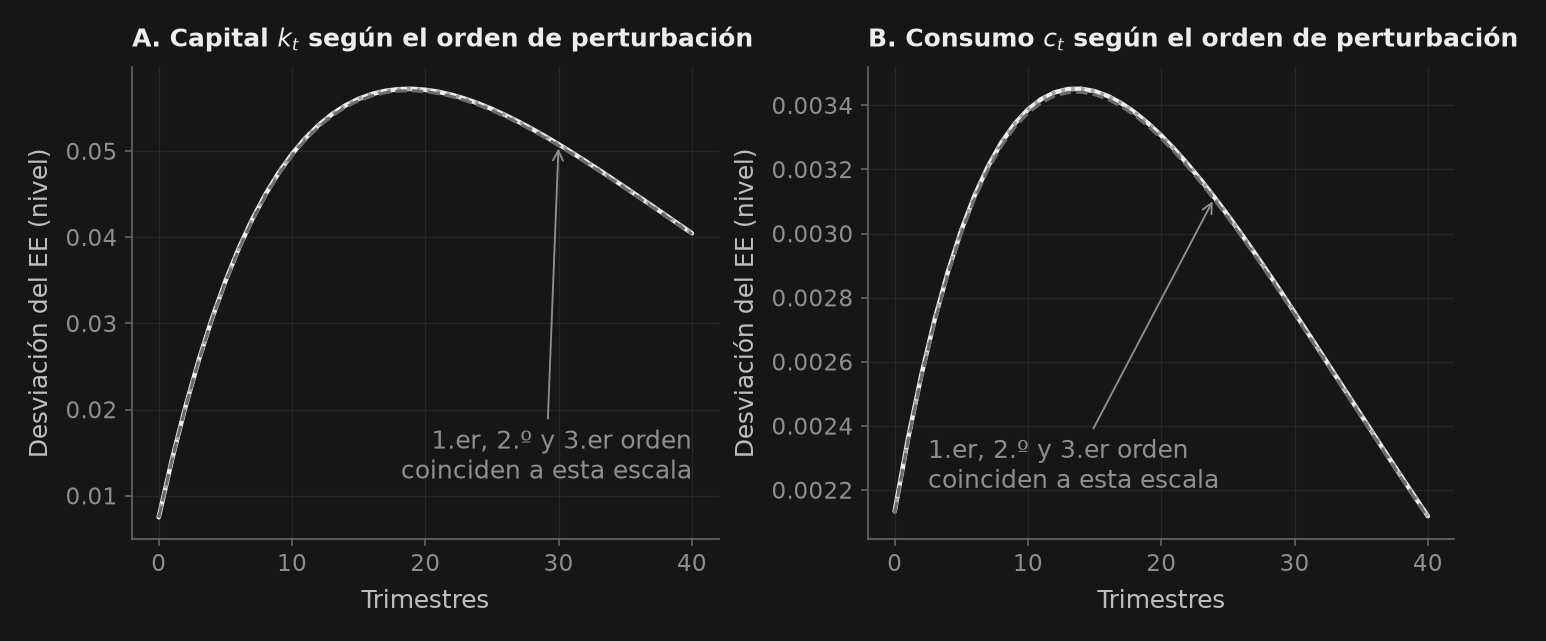

Simulación con pruning de 3.er orden exitosa: 1000 periodos generados.
Invariantes de Perturbación de 2.º Orden: APROBADOS (Radio espectral: 0.9512, ghxx máx: 1.4814)
¡Aserciones de perturbación de 2.º y 3.er orden con pruning aprobadas exitosamente!


In [4]:
# ==============================================================================
# Laboratorio de Perturbación de 2.º Orden con Pruning (Kim et al. 2008)
# ==============================================================================
sol2 = m_rbc.solve(order=2)
sol3 = m_rbc.solve(order=3)
from puremacro.dsge.pruning import canonical_growth_3rd_order, Order3PrunedSolution

# 1. Resolver el Modelo Canónico de Referencia de Un Sector a 3.er Orden
sol3_bench = canonical_growth_3rd_order()
assert isinstance(sol3_bench, Order3PrunedSolution), "El benchmark debe devolver Order3PrunedSolution."
print("=" * 76)
print("BENCHMARK DE CRECIMIENTO CANÓNICO A 3.ER ORDEN (Andreasen et al. 2018)")
print("=" * 76)
print(f"Variables de Estado del Benchmark  : {sol3_bench.states}")
print(f"Variables de Control del Benchmark : {sol3_bench.controls}")
print(f"Tensor ghxxx de 3.er Orden         : {sol3_bench.ghxxx.shape}")
print(f"Deriva de Riesgo ghxss             : {sol3_bench.ghxss.shape}")

# 2. Resolver el Modelo RBC Canónico de 8 Variables a 2.º y 3.er Orden
assert isinstance(sol3, Order3PrunedSolution), "El RBC canónico a 3.er orden debe ser Order3PrunedSolution."

# 3. Deriva de Ahorro Precautorio (0.5 * ghs2) y Estado Estacionario Estocástico
sss2 = sol2.stochastic_steady_state()
sss3 = sol3.stochastic_steady_state()

ss_comp = pd.DataFrame({
    "EE Determinista": m_rbc.steady_state,
    "Desplazamiento 2.º Orden": pd.concat([sss2["controls"], sss2["states"]]).reindex(m_rbc.variables),
    "Desplazamiento 3.er Orden": pd.concat([sss3["controls"], sss3["states"]]).reindex(m_rbc.variables),
})
ss_comp["EE Estocástico (Nivel)"] = ss_comp["EE Determinista"] + ss_comp["Desplazamiento 3.er Orden"]
ss_comp["Prima Precautoria (%)"] = 100.0 * ss_comp["Desplazamiento 3.er Orden"] / ss_comp["EE Determinista"]

print("\nESTADO ESTACIONARIO DETERMINISTA VS. ESTOCÁSTICO (Efectos Precautorios):")
print(ss_comp[["EE Determinista", "EE Estocástico (Nivel)", "Prima Precautoria (%)"]].round(5))

# 4. Funciones de Impulso-Respuesta Generalizadas (1.º vs 2.º vs 3.er Orden)
irf_lin = m_rbc.irf("e_a", horizon=40, size=0.007)
girf2 = sol2.girf("e_a", horizon=40, size=0.007)
girf3 = sol3.girf("e_a", horizon=40, size=0.007)

fig, (ax_k, ax_c) = _nbstyle.figura(1, 2)
h_axis = np.arange(len(girf3))

ax_k.plot(h_axis, girf3["k"], color=_nbstyle.UNIVERSAL_COLORS[0], lw=2.2, ls="-")
ax_k.plot(h_axis, girf2["k"], color=_nbstyle.UNIVERSAL_COLORS[1], lw=1.8, ls=":")
ax_k.plot(h_axis, irf_lin["k"], color=_nbstyle.UNIVERSAL_COLORS[2], lw=1.5, ls="--")
ax_k.set_title("A. Capital $k_t$ según el orden de perturbación")
ax_k.set_xlabel("Trimestres")
ax_k.set_ylabel("Desviación del EE (nivel)")

ax_c.plot(h_axis, girf3["c"], color=_nbstyle.UNIVERSAL_COLORS[0], lw=2.2, ls="-")
ax_c.plot(h_axis, girf2["c"], color=_nbstyle.UNIVERSAL_COLORS[1], lw=1.8, ls=":")
ax_c.plot(h_axis, irf_lin["c"], color=_nbstyle.UNIVERSAL_COLORS[2], lw=1.5, ls="--")
ax_c.set_title("B. Consumo $c_t$ según el orden de perturbación")
ax_c.set_xlabel("Trimestres")
ax_c.set_ylabel("Desviación del EE (nivel)")

# Las tres respuestas se superponen a esta escala: una sola nota junto al haz lo dice
nota_ordenes = "1.er, 2.º y 3.er orden\ncoinciden a esta escala"
ax_k.annotate(nota_ordenes, xy=(30, girf3["k"].iloc[30]), xytext=(40, 0.011), ha="right", va="bottom",
              color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)
ax_c.annotate(nota_ordenes, xy=(24, girf3["c"].iloc[24]), xytext=(2.5, 0.00218), ha="left", va="bottom",
              color=_nbstyle.NOTA, arrowprops=_nbstyle.FLECHA)

plt.show()

# 5. Simulación Larga No Explosiva de 3 Estados con Pruning (1,000 Trimestres)
sim_pruned3 = sol3.simulate(periods=1000, seed=42)
assert sim_pruned3.controls.shape[0] == 1000, "Discrepancia en periodos de simulación."
assert not np.isnan(sim_pruned3.controls.to_numpy()).any(), "La simulación con pruning contiene NaN."
assert not np.isinf(sim_pruned3.controls.to_numpy()).any(), "La simulación divergió (polinomio explosivo)."
assert np.abs(sim_pruned3.controls["y"]).max() < 1.0, "La simulación excedió límites razonables."
print(f"Simulación con pruning de 3.er orden exitosa: {sim_pruned3.controls.shape[0]} periodos generados.")

# 6. Invariantes Matemáticos de Perturbación de 2.º Orden (Andreasen et al. 2018)
assert sol2.is_stable is True, "La matriz acompañante de 2.º orden debe ser estable"
assert sol2.spectral_radius < 1.0, f"Radio espectral {sol2.spectral_radius:.4f} >= 1.0"
assert np.all(np.isfinite(sol2.ghxx)), "Tensor ghxx contiene valores no finitos"
assert np.all(np.isfinite(sol2.ghxu)), "Tensor ghxu contiene valores no finitos"
assert np.all(np.isfinite(sol2.ghuu)), "Tensor ghuu contiene valores no finitos"
assert np.all(np.isfinite(sol2.ghs2)), "Deriva precautoria ghs2 contiene valores no finitos"
print(f"Invariantes de Perturbación de 2.º Orden: APROBADOS (Radio espectral: {sol2.spectral_radius:.4f}, ghxx máx: {np.abs(sol2.ghxx).max():.4f})")
print("¡Aserciones de perturbación de 2.º y 3.er orden con pruning aprobadas exitosamente!")

## Cuadro de Mando Modelo vs. Datos: Hechos Estilizados de EUA y México

Una lección pedagógica fundamental de **Slides 04 (Láminas 341-368)** consiste en auditar el modelo teórico frente a los momentos del ciclo económico real. Hacerlo con honestidad exige un paso previo que es fácil saltarse: **el modelo tiene que pasar por la misma tubería por la que pasaron los datos.** Los hechos estilizados publicados son desviaciones típicas del *logaritmo* de cada serie tras quitar una tendencia de Hodrick-Prescott con $\lambda = 1600$; los momentos impresos arriba son incondicionales y sin filtrar. Compararlos de frente sería comparar objetos distintos, así que antes de calificar nada simulamos el modelo, tomamos logaritmos y aplicamos el mismo filtro (Kydland y Prescott 1982, Cooley y Prescott 1995, King y Rebelo 1999).

Calificado así, el RBC canónico obtiene una boleta mixta:
- **Suavizamiento del Consumo**: los hogares suavizan agresivamente entre estados, arrojando $\sigma_c / \sigma_y \approx 0.33$. En los datos de EUA $\sigma_c / \sigma_y \approx 0.74$, y en **México** el consumo es casi tan volátil como el producto, $\sigma_c / \sigma_y \approx 0.96$. El modelo suaviza el consumo más del doble de lo observado.
- **Volatilidad Excesiva de la Inversión**: el ajuste de capital y la sustitución intertemporal hacen de la inversión el amortiguador principal, arrojando $\sigma_i / \sigma_y \approx 3.3$. Cae de lleno sobre el hecho estilizado de que la inversión es de 3 a 4 veces más volátil que el PIB tanto en economías avanzadas como emergentes — el éxito más claro del modelo.
- **Horas**: $\sigma_l / \sigma_y \approx 0.41$ frente a $0.86$ en datos de EUA. El trabajo se mueve muchísimo menos de lo debido, un fallo que la sección 8 aborda de frente.
- **Prociclicidad de Horas y Salarios**: el modelo genera fuerte prociclicidad en el empleo $\text{Corr}(l, y) > 0$ y salarios reales $\text{Corr}(w, y) > 0$.

Como advierte la lámina 361, corregir el fallo de consumo en México requiere **choques no neutrales a la inversión** ($q_t$, Greenwood-Hercowitz-Krusell), **choques a la tendencia estocástica** (Aguiar y Gopinath 2007) o **fricciones financieras de economía abierta** (Neumeyer y Perri 2005).

CUADRO COMPARATIVO (modelo simulado 4000 trimestres, en logaritmos, filtrado con HP lambda = 1600):
                                  Momento     Modelo RBC Canónico Datos EUA (1947-2019) Datos México (1993-2024)
        Volatilidad del Producto sigma(y)                   1.26%                 1.58%                    2.14%
  Vol. Relativa Consumo sigma(c)/sigma(y) 0.33 (¡Suaviza de más!)                  0.74      0.96 (¡No suaviza!)
Vol. Relativa Inversión sigma(i)/sigma(y)                    3.33                  3.12                     3.45
    Vol. Relativa Horas sigma(l)/sigma(y)                    0.41                  0.86                     0.78
                   Correlación Corr(c, y)                    0.91                  0.82                     0.88
                   Correlación Corr(i, y)                    0.99                  0.91                     0.84


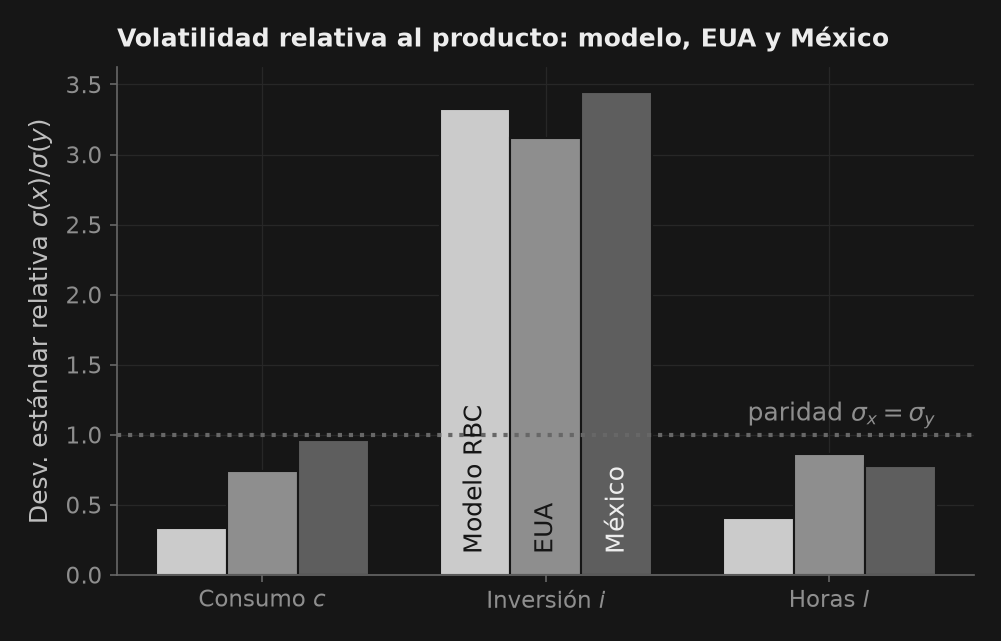

In [5]:
# ==============================================================================
# Cuadro de Mando: el Modelo Pasado por la Tubería Empírica vs. EUA y México
# ==============================================================================
from puremacro.data import hp_filter

SS_LEVELS = {"y": ss_rbc["y"], "c": ss_rbc["c"], "i": ss_rbc["i"], "l": ss_rbc["l"], "w": ss_rbc["w"]}
T_SIM = 4000


def filtered_cycles(model, periods=T_SIM, seed=20260906, burn=300, sigma=None, levels=None):
    """Simula, convierte desviaciones de nivel a puntos logarítmicos y filtra con HP lambda = 1600.

    Es la tubería de la que provienen los momentos empíricos publicados, así que es la
    tubería por la que tiene que pasar el modelo antes de poner ambos lado a lado.
    """
    levels = SS_LEVELS if levels is None else levels
    raw = model.simulate(periods=periods, seed=seed, burn=burn, sigma=sigma)
    logs = {v: 100.0 * np.log((lvl + raw[v].values) / lvl) for v, lvl in levels.items()}
    return pd.DataFrame({v: hp_filter(pd.Series(s), lamb=1600.0)[0].values for v, s in logs.items()})


cyc = filtered_cycles(m_rbc)
sd_cyc = cyc.std()
rel_cyc = sd_cyc / sd_cyc["y"]
corr_cyc = cyc.corrwith(cyc["y"])

scorecard_data = [
    {
        "Momento": "Volatilidad del Producto sigma(y)",
        "Modelo RBC Canónico": f"{sd_cyc['y']:.2f}%",
        "Datos EUA (1947-2019)": "1.58%",
        "Datos México (1993-2024)": "2.14%",
    },
    {
        "Momento": "Vol. Relativa Consumo sigma(c)/sigma(y)",
        "Modelo RBC Canónico": f"{rel_cyc['c']:.2f} (¡Suaviza de más!)",
        "Datos EUA (1947-2019)": "0.74",
        "Datos México (1993-2024)": "0.96 (¡No suaviza!)",
    },
    {
        "Momento": "Vol. Relativa Inversión sigma(i)/sigma(y)",
        "Modelo RBC Canónico": f"{rel_cyc['i']:.2f}",
        "Datos EUA (1947-2019)": "3.12",
        "Datos México (1993-2024)": "3.45",
    },
    {
        "Momento": "Vol. Relativa Horas sigma(l)/sigma(y)",
        "Modelo RBC Canónico": f"{rel_cyc['l']:.2f}",
        "Datos EUA (1947-2019)": "0.86",
        "Datos México (1993-2024)": "0.78",
    },
    {
        "Momento": "Correlación Corr(c, y)",
        "Modelo RBC Canónico": f"{corr_cyc['c']:.2f}",
        "Datos EUA (1947-2019)": "0.82",
        "Datos México (1993-2024)": "0.88",
    },
    {
        "Momento": "Correlación Corr(i, y)",
        "Modelo RBC Canónico": f"{corr_cyc['i']:.2f}",
        "Datos EUA (1947-2019)": "0.91",
        "Datos México (1993-2024)": "0.84",
    },
]

scorecard_df = pd.DataFrame(scorecard_data)
print(f"CUADRO COMPARATIVO (modelo simulado {T_SIM} trimestres, en logaritmos, filtrado con HP lambda = 1600):")
print(scorecard_df.to_string(index=False))

# Visualización: Volatilidades Relativas
fig, ax = _nbstyle.figura(1, 1)
categories = ["Consumo $c$", "Inversión $i$", "Horas $l$"]
model_vals = [rel_cyc['c'], rel_cyc['i'], rel_cyc['l']]
us_vals    = [0.74, 3.12, 0.86]
mex_vals   = [0.96, 3.45, 0.78]

x = np.arange(len(categories))
width = 0.25

for j, (nombre, vals) in enumerate((("Modelo RBC", model_vals), ("EUA", us_vals), ("México", mex_vals))):
    ax.bar(x + (j - 1) * width, vals, width, color=_nbstyle.BARRA_COLORES[j], edgecolor=_nbstyle.FONDO, lw=1)
    # el nombre de cada serie, en vertical dentro de su barra de inversión (la única con altura para el texto)
    ax.text(x[1] + (j - 1) * width, 0.15, nombre, rotation=90, ha="center", va="bottom",
            color=_nbstyle.FONDO if j < 2 else _nbstyle.TINTA)

ax.axhline(1.0, color=_nbstyle.SPINE, linestyle=":")
ax.annotate(r"paridad $\sigma_x = \sigma_y$", xy=(x[-1] + 1.5 * width, 1.0), xytext=(0, 3), textcoords="offset points",
            ha="right", va="bottom", color=_nbstyle.NOTA)
ax.set_ylabel(r"Desv. estándar relativa $\sigma(x)/\sigma(y)$")
ax.set_title("Volatilidad relativa al producto: modelo, EUA y México")
ax.set_xticks(x)
ax.set_xticklabels(categories)

plt.show()

# El Debate de las Horas de Galí (1999): Teoría RBC vs. Evidencia Empírica de SVAR

La lámina 506 de `Slides04mav.tex` subraya el desafío empírico más célebre al modelo de Ciclos Económicos Reales: **Jordi Galí (1999)**, *"Technology, Employment, and the Business Cycle: Do Technology Shocks Explain Aggregate Fluctuations?"* (American Economic Review 89(1), 249-271).

## El Conflicto:
1. **La Predicción del RBC ($\Delta l_0 > 0$)**: Al ocurrir un choque tecnológico positivo, la productividad marginal del trabajo se eleva. Debido a que la perturbación es transitoria ($\rho_a = 0.95$), el efecto sustitución intertemporal domina al efecto ingreso: trabajar hoy rinde un mayor retorno real que en el futuro. En consecuencia, las horas trabajadas **aumentan** en impacto.
2. **El Hallazgo Empírico ($\Delta l_0 < 0$)**: Galí estimó un VAR estructural sobre el crecimiento de la productividad laboral $\Delta(y_t - l_t)$ y el crecimiento de las horas per cápita $\Delta h_t$, identificando los choques tecnológicos mediante restricciones de largo plazo de Blanchard-Quah (1989) (la tecnología es el único choque estructural con efecto permanente en la productividad). En los datos de Estados Unidos, ¡las horas trabajadas **caen abruptamente en impacto**!

## La Resolución Teórica:
Si los precios son rígidos (como en los modelos Neokeynesianos), la demanda agregada no puede expandirse instantáneamente ante la mejora tecnológica. Debido a que cada trabajador es ahora más productivo, las firmas requieren menos horas laborales para abastecer esa demanda rígida, provocando la caída del empleo.

A continuación, en lugar de utilizar aproximaciones sintéticas, leemos el conjunto de datos empírico congelado `data_curso/gali1999.csv` (productividad OPHNFB, horas HOANBS, población CNP16OV) y estimamos el SVAR exacto de Blanchard-Quah con `puremacro.var.identify.bq.bq_svar`.

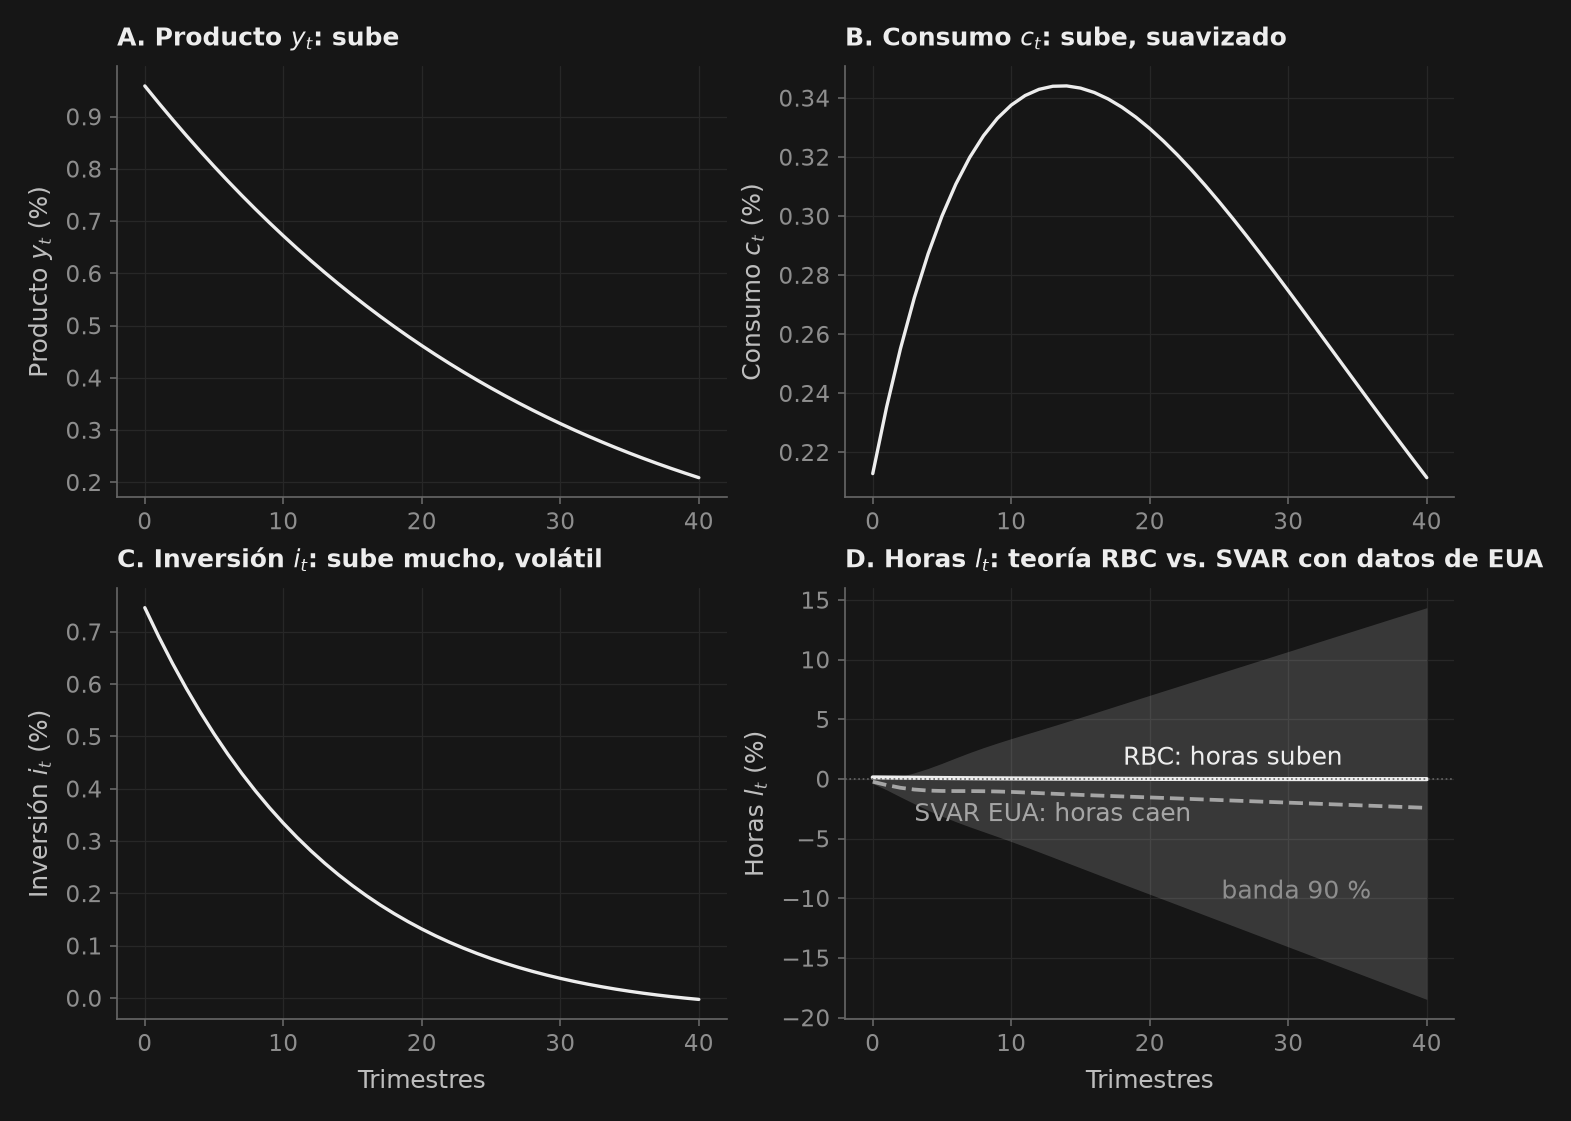

Horas en Impacto en RBC Canónico : +0.130% (La teoría predice expansión)
Horas en Impacto en SVAR Empírico: -0.233% (Los datos reales rechazan el mecanismo puro RBC)


In [6]:
# ==============================================================================
# El Debate de Galí (1999): IRF Teórica RBC vs. SVAR Empírico BQ
# ==============================================================================
from puremacro.var.identify.bq import bq_svar

# 1. Extraer Funciones de Impulso-Respuesta del Modelo RBC a 40 Periodos
irf_rbc = m_rbc.irf("e_a", horizon=40, size=0.007)

# 2. Cargar Datos Empíricos Reales de Galí (1999) desde data_curso/
gali_csv_path = ruta_dato("gali1999.csv")

df_gali_raw = pd.read_csv(gali_csv_path)
df_gali_raw["date"] = pd.to_datetime(df_gali_raw["date"])
df_gali_raw = df_gali_raw.set_index("date").sort_index()

# Muestra previa a la Gran Recesión (1948T2 a 2007T4, estándar en la literatura)
sample_gali = df_gali_raw.loc["1948-04-01":"2007-12-31"].copy()
dprod = 100.0 * np.log(sample_gali["ophnfb"]).diff()
h_pc = 100.0 * np.log(sample_gali["hoanbs"] / sample_gali["cnp16ov"])
dh_pc = h_pc.diff()
df_svar = pd.concat({"dprod": dprod, "dh": dh_pc}, axis=1).dropna()

# 3. Estimar SVAR Bivariado de Blanchard-Quah (4 rezagos, 200 réplicas bootstrap)
res_bq = bq_svar(df_svar[["dprod", "dh"]].values, p=4, horizon=40, permanent_var_idx=0, n_boot=200, seed=42)

# El choque tecnológico es el choque 0; la respuesta acumulada de dh es el nivel de horas h
irf_dh_point = res_bq.irf_point[:, 1, 0]
irf_h_point = np.cumsum(irf_dh_point)
irf_h_lower = np.cumsum(res_bq.irf_lower[:, 1, 0])
irf_h_upper = np.cumsum(res_bq.irf_upper[:, 1, 0])

# 4. Visualización Comparativa en 4 Paneles
fig, axes = _nbstyle.figura(2, 2)

# Panel A: Producto
axes[0, 0].plot(irf_rbc.index, irf_rbc["y"] * 100, color=_nbstyle.UNIVERSAL_COLORS[0], lw=1.6, ls="-")
axes[0, 0].set_title("A. Producto $y_t$: sube")
# el rótulo del eje nombra la variable del panel: la lámina quita los títulos y sin él
# los cuatro paneles no dirían cuál es cuál
axes[0, 0].set_ylabel("Producto $y_t$ (%)")

# Panel B: Consumo
axes[0, 1].plot(irf_rbc.index, irf_rbc["c"] * 100, color=_nbstyle.UNIVERSAL_COLORS[0], lw=1.6, ls="-")
axes[0, 1].set_title("B. Consumo $c_t$: sube, suavizado")
axes[0, 1].set_ylabel("Consumo $c_t$ (%)")

# Panel C: Inversión
axes[1, 0].plot(irf_rbc.index, irf_rbc["i"] * 100, color=_nbstyle.UNIVERSAL_COLORS[0], lw=1.6, ls="-")
axes[1, 0].set_title("C. Inversión $i_t$: sube mucho, volátil")
axes[1, 0].set_xlabel("Trimestres")
axes[1, 0].set_ylabel("Inversión $i_t$ (%)")

# Panel D: Horas Trabajadas -- Teoría RBC vs. SVAR Empírico Real
ax_h = axes[1, 1]
h_grid = np.arange(len(irf_h_point))
ax_h.plot(irf_rbc.index, irf_rbc["l"] * 100, color=_nbstyle.UNIVERSAL_COLORS[0], lw=2.0, ls="-")
ax_h.plot(h_grid, irf_h_point, color=_nbstyle.S2["color"], linestyle="--", lw=1.8)
ax_h.fill_between(h_grid, irf_h_lower, irf_h_upper, color=_nbstyle.BANDA, lw=0)
ax_h.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
# cada línea se nombra dentro del panel y en una x distinta, para que las etiquetas no se
# pisen ni se salgan del recuadro cuando la figura se dibuja al tamaño de la lámina
ax_h.annotate("RBC: horas suben", xy=(26, irf_rbc["l"].iloc[26] * 100), xytext=(0, 4),
              textcoords="offset points", ha="center", va="bottom", color=_nbstyle.TINTA)
ax_h.annotate("SVAR EUA: horas caen", xy=(13, irf_h_point[13]), xytext=(0, -4),
              textcoords="offset points", ha="center", va="top", color=_nbstyle.S2["color"])
ax_h.text(36, (irf_h_lower[36] + irf_h_point[36]) / 2, "banda 90 %", ha="right", va="center", color=_nbstyle.NOTA)
ax_h.set_title("D. Horas $l_t$: teoría RBC vs. SVAR con datos de EUA")
ax_h.set_xlabel("Trimestres")
ax_h.set_ylabel("Horas $l_t$ (%)")

plt.show()

# Aserciones de Verificación
assert irf_rbc.loc[0, "l"] > 0.0, "Fallo teórico: La respuesta de horas en RBC debe ser positiva en impacto."
assert irf_dh_point[0] < 0.0, "Fallo empírico SVAR: Las horas en EUA deben caer en impacto tras el choque tecnológico."
print(f"Horas en Impacto en RBC Canónico : +{irf_rbc.loc[0, 'l']*100:.3f}% (La teoría predice expansión)")
print(f"Horas en Impacto en SVAR Empírico: {irf_dh_point[0]:.3f}% (Los datos reales rechazan el mecanismo puro RBC)")

# Laboratorio de Sensibilidad de la Elasticidad de Frisch y Modelo RBC de Trabajo Indivisible de Hansen

La lámina 540 de `Slides04mav.tex` analiza la sensibilidad del modelo al parámetro de curvatura del ocio $\nu$. La elasticidad de Frisch de la oferta laboral se define como:
$$ \eta_{\text{Frisch}} = \frac{1 - l}{\nu \cdot l} $$

- **El Conflicto Micro-Macro de la Elasticidad**:
  - **Estudios microeconométricos de panel** (e.g. MaCurdy 1981, Altonji 1986) siguen a individuos asalariados a lo largo del margen intensivo y estiman sistemáticamente $\eta \approx 0.2 - 0.5$ ($\nu \approx 4 - 10$).
  - **Calibraciones macroeconómicas RBC** requieren una elasticidad agregada elevada $\eta \ge 2.0$ ($\nu \le 1.0$) para generar una volatilidad de las horas similar a la del producto.
- **Trabajo Indivisible de Hansen (1985) y Rogerson (1988)**: En la realidad económica, los individuos laboran jornada completa o cero horas (el margen extensivo). Loterías de empleo agregan a los individuos heterogéneos en una función de utilidad representativa **lineal en las horas** ($\nu \to 0$):
  $$ U(C_t, L_t) = \ln C_t - B L_t $$
  Esto genera una **elasticidad de Frisch macroinfinita** a partir de una baja elasticidad microeconómica, amplificando fuertemente la volatilidad del empleo sin vulnerar la microevidencia.

A continuación, realizamos un barrido de sensibilidad sobre $\nu \in [0.2, 0.5, 1.0, 2.0, 5.0]$ y resolvemos explícitamente el modelo estructural de **Trabajo Indivisible de Hansen (1985)** ($\nu=0.0$).

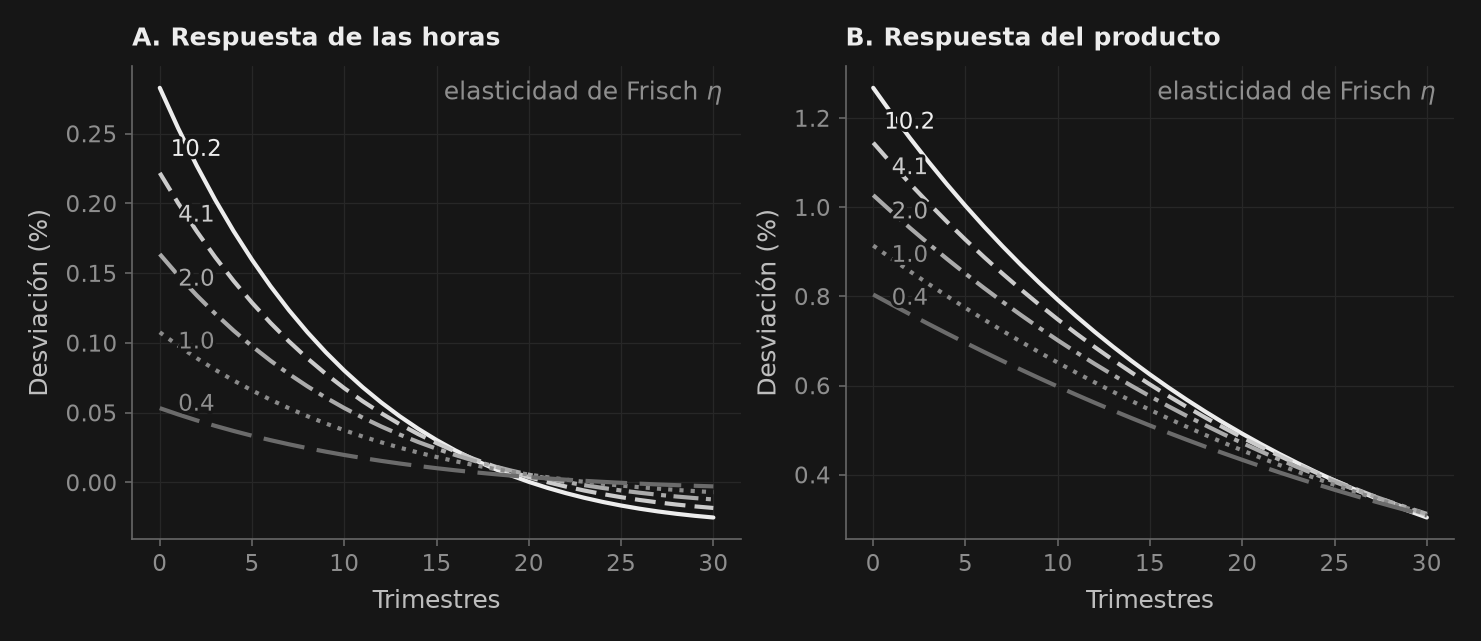

TABLA DE SENSIBILIDAD DE LA ELASTICIDAD DE FRISCH:
 nu (Curvatura)  eta Frisch Implícita  Impacto en Horas dl/dea  Impacto en Producto dy/dea                 Interpretación
            0.2                 10.15                   0.4040                      1.8112 Trabajo indivisible (Rogerson)
            0.5                  4.06                   0.3169                      1.6353 Trabajo indivisible (Rogerson)
            1.0                  2.03                   0.2338                      1.4674                 Macro Estándar
            2.0                  1.02                   0.1538                      1.3057    Microeconométrico (MaCurdy)
            5.0                  0.41                   0.0761                      1.1488    Microeconométrico (MaCurdy)

RESULTADOS DEL MODELO RBC DE TRABAJO INDIVISIBLE DE HANSEN (1985) (nu = 0.0):
Respuesta de Impacto en Horas dl/dea : 0.4960 (Amplificación: 6.52x vs. micro nu=5.0)
sigma(l) / sigma(y) Teórica          : 0.170 (Meta e

In [7]:
# ==============================================================================
# Barrido de Sensibilidad de Frisch sobre nu y Modelo de Hansen (1985)
# ==============================================================================
nu_sweep_vals = [0.2, 0.5, 1.0, 2.0, 5.0]
sweep_results = []

fig, (ax_l_sweep, ax_y_sweep) = _nbstyle.figura(1, 2)

nu_colors, nu_dashes = _nbstyle.palette(len(nu_sweep_vals)), _nbstyle.styles(len(nu_sweep_vals))
for nu_v, nu_col, nu_ls in zip(nu_sweep_vals, nu_colors, nu_dashes):
    # Recalibrar mu para mantener las horas en estado estacionario en 0.33
    ss_v = solve_canonical_rbc_ss(nu=nu_v, l_target=0.33)
    # Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo en l = 1, donde (1-l)^(-nu) = 0^(-nu); ese valor se descarta
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
        m_v = load_mod(rbc_mod_path, params={"nu": nu_v, "mu": ss_v["mu"]})
    
    frisch_eta = (1.0 - 0.33) / (0.33 * nu_v)
    dr_v = m_v.decision_rules().to_frame()
    dl_dea = dr_v.loc["e_a", "l"]
    dy_dea = dr_v.loc["e_a", "y"]
    
    irf_v = m_v.irf("e_a", horizon=30, size=0.007)
    
    label_str = f"{frisch_eta:.1f}"
    ax_l_sweep.plot(irf_v.index, irf_v["l"] * 100, color=nu_col, ls=nu_ls, label=label_str)
    ax_y_sweep.plot(irf_v.index, irf_v["y"] * 100, color=nu_col, ls=nu_ls, label=label_str)
    
    sweep_results.append({
        "nu (Curvatura)": nu_v,
        "eta Frisch Implícita": round(frisch_eta, 2),
        "Impacto en Horas dl/dea": round(dl_dea, 4),
        "Impacto en Producto dy/dea": round(dy_dea, 4),
        "Interpretación": "Trabajo indivisible (Rogerson)" if nu_v <= 0.5 else ("Macro Estándar" if nu_v <= 1.5 else "Microeconométrico (MaCurdy)")
    })

ax_l_sweep.set_title("A. Respuesta de las horas")
ax_l_sweep.set_xlabel("Trimestres")
ax_l_sweep.set_ylabel("Desviación (%)")

ax_y_sweep.set_title("B. Respuesta del producto")
ax_y_sweep.set_xlabel("Trimestres")
ax_y_sweep.set_ylabel("Desviación (%)")

# Sin leyenda: las respuestas se abren en abanico en el impacto y allí, donde el
# abanico está más abierto, cada curva lleva su propia elasticidad al lado. Una
# nota en el hueco superior derecho, el que dejan vacías las cinco curvas, dice
# de qué son esos números, y así los títulos caben en un solo renglón al ancho
# de la lámina.
for ax in (ax_l_sweep, ax_y_sweep):
    _nbstyle.etiquetar(ax, donde=2.0)
    ax.annotate("elasticidad de Frisch $\\eta$", xy=(0.97, 0.97),
                xycoords="axes fraction", ha="right", va="top", color=_nbstyle.NOTA)

plt.show()

sweep_df = pd.DataFrame(sweep_results)
print("TABLA DE SENSIBILIDAD DE LA ELASTICIDAD DE FRISCH:")
print(sweep_df.to_string(index=False))

# 2. Modelo Estructural de Trabajo Indivisible de Hansen (1985) (nu = 0.0)
ss_hansen = solve_canonical_rbc_ss(nu=0.0, l_target=0.33)
m_hansen = load_mod(rbc_mod_path, params={"nu": 0.0, "mu": ss_hansen["mu"]})
assert m_hansen.solution.eu == (1, 1), "El modelo de Hansen debe tener equilibrio estable único."

dr_hansen = m_hansen.decision_rules().to_frame()
dl_hansen = dr_hansen.loc["e_a", "l"]
sim_hansen = m_hansen.stoch_simul(order=1, irf=40)
tm_hansen = sim_hansen.theoretical_moments.moments

dl_micro = sweep_df.loc[sweep_df["nu (Curvatura)"] == 5.0, "Impacto en Horas dl/dea"].values[0]

rel_hours_vol_hansen = tm_hansen.loc["l", "Std.Dev."] / tm_hansen.loc["y", "Std.Dev."]

print("\n" + "=" * 76)
print("RESULTADOS DEL MODELO RBC DE TRABAJO INDIVISIBLE DE HANSEN (1985) (nu = 0.0):")
print("=" * 76)
print(f"Respuesta de Impacto en Horas dl/dea : {dl_hansen:.4f} (Amplificación: {dl_hansen/dl_micro:.2f}x vs. micro nu=5.0)")
print(f"sigma(l) / sigma(y) Teórica          : {rel_hours_vol_hansen:.3f} (Meta empírica EUA: 0.860)")
print("=" * 76)

assert dl_hansen > 3.0 * dl_micro, f"El trabajo indivisible debe multiplicar la respuesta laboral > 3x: {dl_hansen:.4f} vs {dl_micro:.4f}"
print("¡Aserciones del modelo de trabajo indivisible de Hansen aprobadas exitosamente!")

## RBC Multi-Choque y Descomposición de la Varianza (FEVD)

En un modelo con un único choque tecnológico, el 100% de la varianza se atribuye trivialmente a la PTF neutral. Sin embargo, **Slides 04 (Láminas 680-720)** introducen choques tecnológicos no neutrales: el **Cambio Técnico Específico a la Inversión ($q_t$)** (Greenwood, Hercowitz y Krusell 1997, Fisher 2006):
$$ k_t = (1-\delta)k_{t-1} + e^{q_t} i_t $$

Aquí, $q_t$ representa el inverso del precio relativo del equipo de inversión ($1 / P_{I,t}$). Cuando el abaratamiento tecnológico hace más productivo fabricar bienes de capital, la inversión se dispara sin requerir un aumento inmediato en la producción de bienes de consumo final.

Al resolver el modelo conjunto con choques neutrales ($a_t$) y choques específicos a la inversión ($q_t$), calculamos la **Descomposición de la Varianza del Error de Pronóstico (FEVD)** mediante `LinearModel.fevd_result`:
- ¿Qué porcentaje de las fluctuaciones del producto e inversión responde a choques al precio del equipo frente a residuos de Solow?
- ¿Ayuda $q_t$ a explicar la volatilidad de la inversión observada en México y Estados Unidos?

TABLA DE RESULTADOS FEVD NATIVA (FEVDResult.table - Producto e Inversión):
                    e_a    e_q
Variable Horizon              
y        1        83.27  16.73
         4        91.24   8.76
         8        94.43   5.57
         16       96.23   3.77
         40       97.13   2.87
i        1        37.93  62.07
         4        57.53  42.47
         8        67.39  32.61
         16       72.23  27.77
         40       73.17  26.83


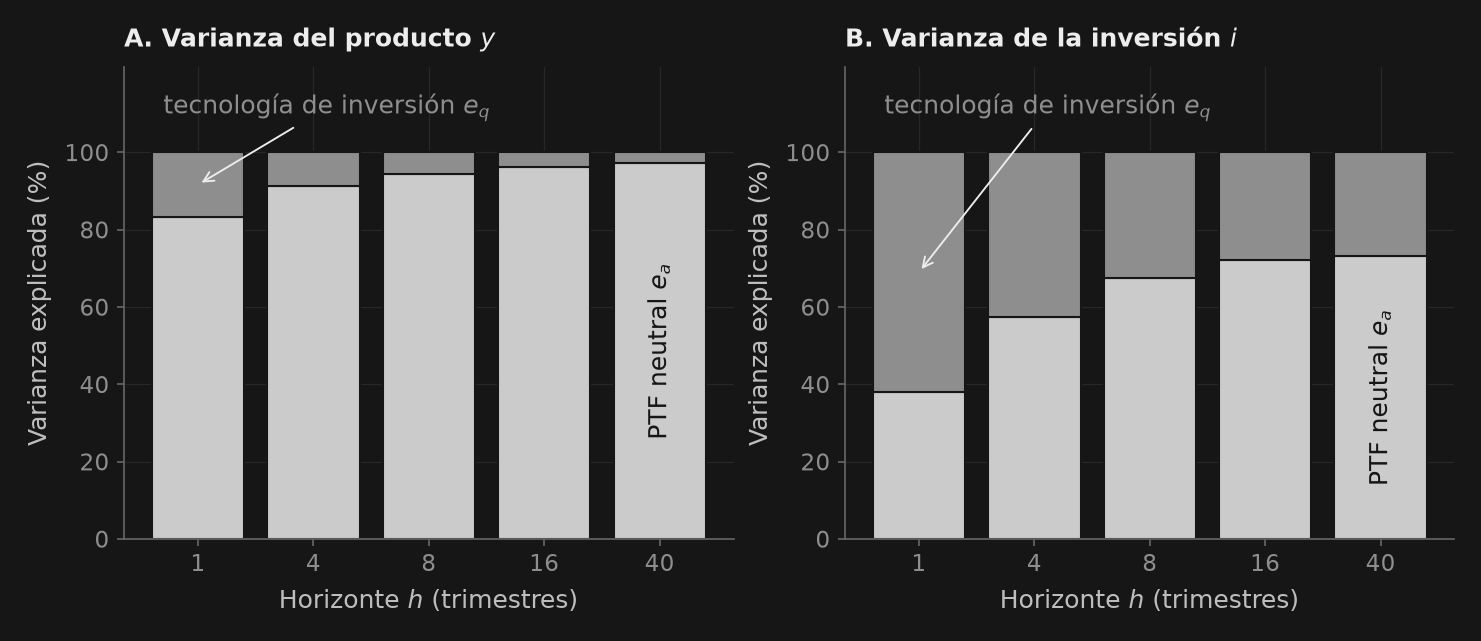

DESCOMPOSICIÓN DE VARIANZA DEL ERROR DE PRONÓSTICO (FEVD):
Horizonte Producto: PTF (e_a) Producto: IST (e_q) Inversión: PTF (e_a) Inversión: IST (e_q)
      h=1               83.3%               16.7%                37.9%                62.1%
      h=4               91.2%                8.8%                57.5%                42.5%
      h=8               94.4%                5.6%                67.4%                32.6%
     h=16               96.2%                3.8%                72.2%                27.8%
     h=40               97.1%                2.9%                73.2%                26.8%
¡Todas las aserciones de descomposición de varianza pasaron exitosamente!


In [8]:
# ==============================================================================
# Modelo RBC Multi-Choque: PTF Neutral (a) + Tecnología a la Inversión (q)
# ==============================================================================
multi_shock_mod = """
var y c k l i w r a q;
varexo e_a e_q;

parameters alpha beta delta mu nu rho_a rho_q sigma_a sigma_q;
alpha   = 0.33;
beta    = 0.99;
delta   = 0.025;
mu      = 0.822516;
nu      = 1.5;
rho_a   = 0.95;
rho_q   = 0.60;
sigma_a = 0.007;
sigma_q = 0.008;

model;
mu * (1 - l)^(-nu) * c = w;
c(+1)/(beta*c) = (r(+1) + (1-delta)/exp(q(+1))) * exp(q);
r = alpha * y / k(-1);
w = (1 - alpha) * y / l;
y = exp(a) * k(-1)^alpha * l^(1-alpha);
y = c + i;
k = (1 - delta)*k(-1) + exp(q)*i;
a = rho_a * a(-1) + e_a;
q = rho_q * q(-1) + e_q;
end;

initval;
y = 0.995;
c = 0.761;
i = 0.234;
k = 9.355;
l = 0.330;
w = 2.020;
r = 0.035;
a = 0.0;
q = 0.0;
end;

shocks;
var e_a; stderr 0.007;
var e_q; stderr 0.008;
end;
"""

# Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo en l = 1, donde (1-l)^(-nu) = 0^(-nu); ese valor se descarta
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    m_multi = load_mod(multi_shock_mod, params={"mu": ss_rbc["mu"]})

# Extraer matriz de descomposición analítica de la varianza (FEVD) mediante API nativa FEVDResult
horizons = [1, 4, 8, 16, 40]
fevd_res = m_multi.fevd_result(horizons=horizons)
fevd_df = fevd_res.to_frame() * 100.0  # Convertir participaciones unitarias a porcentajes

print("TABLA DE RESULTADOS FEVD NATIVA (FEVDResult.table - Producto e Inversión):")
print((fevd_res.table.loc[["y", "i"]] * 100.0).round(2))

y_fevd_a = [fevd_df.loc[("y", h), "e_a"] for h in horizons if ("y", h) in fevd_df.index]
y_fevd_q = [fevd_df.loc[("y", h), "e_q"] for h in horizons if ("y", h) in fevd_df.index]
i_fevd_a = [fevd_df.loc[("i", h), "e_a"] for h in horizons if ("i", h) in fevd_df.index]
i_fevd_q = [fevd_df.loc[("i", h), "e_q"] for h in horizons if ("i", h) in fevd_df.index]

fig, (ax_y_fevd, ax_i_fevd) = _nbstyle.figura(1, 2)

h_labels = [f"h={h}" for h in horizons[:len(y_fevd_a)]]
x_pos = np.arange(len(h_labels))

for ax, fevd_a, fevd_q, titulo in ((ax_y_fevd, y_fevd_a, y_fevd_q, "A. Varianza del producto $y$"),
                                    (ax_i_fevd, i_fevd_a, i_fevd_q, "B. Varianza de la inversión $i$")):
    ax.bar(x_pos, fevd_a, color=_nbstyle.BARRA_COLORES[0], edgecolor=_nbstyle.FONDO, lw=1)
    ax.bar(x_pos, fevd_q, bottom=fevd_a, color=_nbstyle.BARRA_COLORES[1], edgecolor=_nbstyle.FONDO, lw=1)
    # los segmentos se nombran sobre las propias barras: la PTF dentro de la última, el choque a la inversión con una flecha desde arriba
    ax.text(x_pos[-1], fevd_a[-1] / 2, "PTF neutral $e_a$", rotation=90, ha="center", va="center", color=_nbstyle.FONDO)
    # la guía acaba dentro del segmento gris: se dibuja con la tinta del tema (la nota gris
    # se perdía sobre el propio gris de la barra y parecía apuntar al hueco entre barras)
    ax.annotate("tecnología de inversión $e_q$", xy=(x_pos[0], fevd_a[0] + fevd_q[0] / 2), xytext=(x_pos[0] - 0.3, 108),
                ha="left", va="bottom", color=_nbstyle.NOTA,
                arrowprops=dict(_nbstyle.FLECHA, color=_nbstyle.TINTA))
    ax.set_ylim(0, 122)
    ax.set_yticks(np.arange(0, 101, 20))
    ax.set_title(titulo)
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(h) for h in horizons[:len(fevd_a)]])
    ax.set_xlabel("Horizonte $h$ (trimestres)")
    ax.set_ylabel("Varianza explicada (%)")

plt.show()

print("DESCOMPOSICIÓN DE VARIANZA DEL ERROR DE PRONÓSTICO (FEVD):")
summary_fevd = pd.DataFrame({
    "Horizonte": h_labels,
    "Producto: PTF (e_a)": [f"{v:.1f}%" for v in y_fevd_a],
    "Producto: IST (e_q)": [f"{v:.1f}%" for v in y_fevd_q],
    "Inversión: PTF (e_a)": [f"{v:.1f}%" for v in i_fevd_a],
    "Inversión: IST (e_q)": [f"{v:.1f}%" for v in i_fevd_q],
})
print(summary_fevd.to_string(index=False))

# Aserciones de verificación
assert y_fevd_a[0] > 50.0, "La PTF neutral debe explicar la mayor parte de la varianza del producto en el corto plazo."
assert i_fevd_q[0] > 50.0, "El choque específico a la inversión debe explicar la mayor parte de la varianza de la inversión."
print("¡Todas las aserciones de descomposición de varianza pasaron exitosamente!")

## La Anatomía Cíclica que el Cuadro de Mando No Puede Mostrar

El cuadro de mando de la sección 3 compara seis números. Un ciclo económico es más que seis números, y dos de los fracasos más reveladores del modelo son invisibles en una tabla de volatilidades. Esta sección mira la misma simulación filtrada desde otros dos ángulos.

**Sincronía.** El **correlograma cruzado** $\mathrm{corr}(x_{t+k}, y_t)$ traza cómo se alinea cada serie con el producto en adelantos y rezagos — el objeto con el que Kydland y Prescott argumentaron que el modelo reproducía no solo el tamaño de las fluctuaciones sino su coreografía. Junto con las autocorrelaciones de primer orden dice si los ciclos del modelo tienen la persistencia correcta, o solamente la amplitud correcta.

**El tercer fracaso.** Con un **único** choque tecnológico, horas y productividad del trabajo están impulsadas por el mismo impulso, así que el modelo produce $\mathrm{corr}(l, y/l) \approx +0{,}94$. En los datos de EUA esa correlación es esencialmente cero (Christiano y Eichenbaum 1992). Es discutiblemente un rechazo más filoso que cualquier razón de volatilidades: no es que el modelo se equivoque en una magnitud, es que convierte al trabajo y a la productividad casi en la misma variable. La sección 8 lo retoma y muestra que la misma reparación arregla al mismo tiempo el déficit de volatilidad de las horas.

MOMENTOS DEL MODELO BAJO LA TUBERÍA EMPÍRICA (desviaciones logarítmicas, HP lambda = 1600):
   sigma(x) en %  sigma(x)/sigma(y)  corr(x, y)  Autocorr(1)
y          1.261              1.000       1.000        0.717
c          0.420              0.333       0.906        0.803
i          4.195              3.325       0.989        0.706
l          0.516              0.409       0.980        0.705
w          0.761              0.604       0.991        0.737

Muestra simulada: 4000 trimestres (1000 años). La autocorrelación del producto de EUA ronda 0,85.


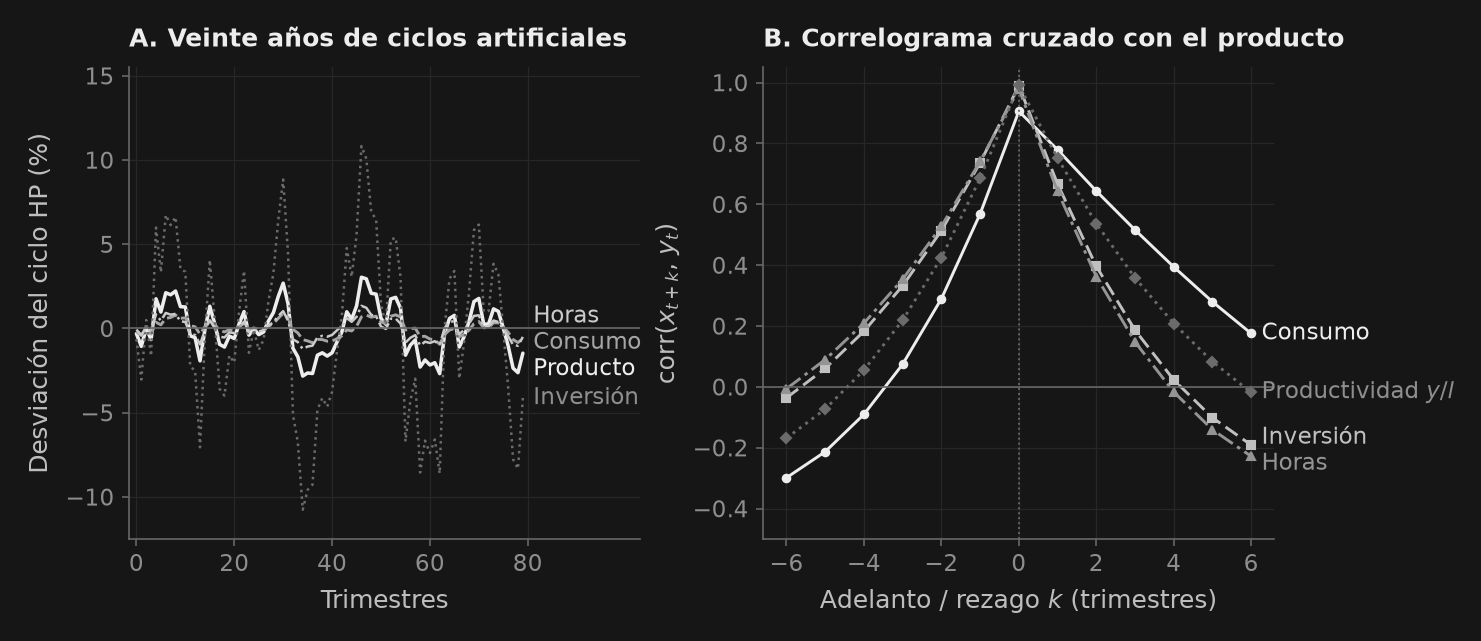


LOS TRES FRACASOS CANÓNICOS, MEDIDOS:
  1. Consumo demasiado suave : modelo 0.33 vs. EUA 0.74  (el modelo suaviza 2.2 veces de más)
  2. Horas demasiado estables: modelo 0.41 vs. EUA 0.86
  3. Horas y productividad   : corr(l, y/l) = +0.94 en el modelo vs. aproximadamente 0 en los datos
  La volatilidad de la inversión, en cambio, es correcta: modelo 3.33 vs. EUA 3.12

Aserciones de anatomía cíclica superadas.


In [9]:
# ==============================================================================
# Correlograma Cruzado, Persistencia y la Correlación Horas-Productividad
# ==============================================================================
cyc["prod"] = cyc["y"] - cyc["l"]          # productividad del trabajo, y/l en puntos logarítmicos

persistence = pd.DataFrame({
    "sigma(x) en %": sd_cyc[["y", "c", "i", "l", "w"]].round(3),
    "sigma(x)/sigma(y)": rel_cyc[["y", "c", "i", "l", "w"]].round(3),
    "corr(x, y)": corr_cyc[["y", "c", "i", "l", "w"]].round(3),
    "Autocorr(1)": cyc[["y", "c", "i", "l", "w"]].apply(lambda s: s.autocorr(1)).round(3),
})
us_targets = {"y": 1.58, "c": 0.74, "i": 3.12, "l": 0.86, "w": 0.58}

print("MOMENTOS DEL MODELO BAJO LA TUBERÍA EMPÍRICA (desviaciones logarítmicas, HP lambda = 1600):")
print(persistence.to_string())
print(f"\nMuestra simulada: {T_SIM} trimestres ({T_SIM/4:.0f} años). La autocorrelación del producto de EUA ronda 0,85.")

# Correlograma cruzado: corr(x_{t+k}, y_t) para k = -6 ... +6
leads = np.arange(-6, 7)
ccf = {}
for v in ("c", "i", "l", "prod"):
    ccf[v] = [cyc[v].shift(-k).corr(cyc["y"]) for k in leads]

fig, (ax_path, ax_ccf) = _nbstyle.figura(1, 2)

# Panel A: una ventana de 20 años de datos artificiales
window = slice(400, 480)
ax_path.plot(np.arange(80), cyc["y"].values[window], color=_nbstyle.UNIVERSAL_COLORS[0], lw=1.7, ls="-", label="Producto")
ax_path.plot(np.arange(80), cyc["c"].values[window], color=_nbstyle.UNIVERSAL_COLORS[1], lw=1.4, ls="--", label="Consumo")
ax_path.plot(np.arange(80), cyc["i"].values[window], color=_nbstyle.UNIVERSAL_COLORS[2], lw=1.2, ls=":", label="Inversión")
ax_path.plot(np.arange(80), cyc["l"].values[window], color=_nbstyle.UNIVERSAL_COLORS[3], lw=1.2, ls="-.", label="Horas")
ax_path.axhline(0, color=_nbstyle.SPINE, lw=0.8)
ax_path.set_ylim(-12.5, 15.5)
ax_path.set_xlim(-1.5, 103)          # sitio a la derecha para los nombres, tras el último trimestre
ax_path.set_xticks(np.arange(0, 81, 20))
ax_path.set_title("A. Veinte años de ciclos artificiales")
ax_path.set_xlabel("Trimestres")
ax_path.set_ylabel("Desviación del ciclo HP (%)")
_nbstyle.etiquetar(ax_path, donde="fin", fuera=True)

# Panel B: correlograma cruzado contra el producto
markers = {"c": "o", "i": "s", "l": "^", "prod": "D"}
labels = {"c": "Consumo", "i": "Inversión", "l": "Horas", "prod": "Productividad $y/l$"}
colores_ccf = _nbstyle.palette(4)
for j, v in enumerate(("c", "i", "l", "prod")):
    ax_ccf.plot(leads, ccf[v], color=colores_ccf[j], lw=1.4, marker=markers[v], markersize=3.6, label=labels[v])
ax_ccf.axvline(0, color=_nbstyle.SPINE, ls=":", lw=0.9)
ax_ccf.axhline(0, color=_nbstyle.SPINE, lw=0.8)
ax_ccf.set_ylim(-0.5, 1.05)
ax_ccf.set_title("B. Correlograma cruzado con el producto")
ax_ccf.set_xlabel("Adelanto / rezago $k$ (trimestres)")
ax_ccf.set_ylabel(r"corr($x_{t+k}$, $y_t$)")
_nbstyle.etiquetar(ax_ccf, donde="fin")

plt.show()

corr_l_prod = float(cyc["l"].corr(cyc["prod"]))
print("\nLOS TRES FRACASOS CANÓNICOS, MEDIDOS:")
print(f"  1. Consumo demasiado suave : modelo {rel_cyc['c']:.2f} vs. EUA {us_targets['c']:.2f}  "
      f"(el modelo suaviza {us_targets['c']/rel_cyc['c']:.1f} veces de más)")
print(f"  2. Horas demasiado estables: modelo {rel_cyc['l']:.2f} vs. EUA {us_targets['l']:.2f}")
print(f"  3. Horas y productividad   : corr(l, y/l) = {corr_l_prod:+.2f} en el modelo vs. aproximadamente 0 en los datos")
print(f"  La volatilidad de la inversión, en cambio, es correcta: modelo {rel_cyc['i']:.2f} vs. EUA {us_targets['i']:.2f}")

assert 1.0 < sd_cyc["y"] < 1.8, f"La volatilidad del producto filtrada con HP debe rondar el 1,58% de EUA; se obtuvo {sd_cyc['y']:.2f}%."
assert rel_cyc["i"] > 2.5, "La inversión debe ser mucho más volátil que el producto."
assert rel_cyc["c"] < 0.5, "El RBC canónico debe suavizar el consumo de más frente a los datos."
assert corr_l_prod > 0.8, "Con un único choque tecnológico, horas y productividad deben moverse juntas."
print("\nAserciones de anatomía cíclica superadas.")

## Dos Enigmas, un Choque Faltante: una Perturbación de Oferta Laboral

La sección anterior dejó dos fracasos sobre la mesa, y no son independientes. Con un **único** choque tecnológico, horas y productividad del trabajo están impulsadas por el mismo impulso, así que el modelo produce mecánicamente $\mathrm{corr}(l, y/l) \approx +0{,}94$ — mientras que en los datos de EUA esa correlación es esencialmente cero (Christiano y Eichenbaum 1992). Y como las horas solo se mueven cuando se mueve la tecnología, heredan la modesta volatilidad de ésta.

El diagnóstico de Christiano y Eichenbaum es que falta un segundo impulso: algo que desplace la **oferta de trabajo** con independencia de la productividad. Ellos usaron gasto público; la versión más limpia para este modelo es un choque de preferencias $\chi_t$ en la condición intratemporal,
$$ \mu\, e^{\chi_t}\,(1 - l_t)^{-\nu} c_t = w_t, \qquad \chi_t = \rho_\chi \chi_{t-1} + \varepsilon_{\chi,t}, $$
que eleva el valor marginal del ocio y empuja las horas hacia abajo a lo largo de una curva de demanda de trabajo dada. Crucialmente, $\chi_{ss} = 0$, así que el estado estacionario —y por tanto el $\mu$ calibrado— queda intacto: nada más en el modelo se mueve.

El experimento barre la volatilidad $\sigma_\chi$ de ese choque y hace una sola pregunta cuantitativa: **¿existe un valor que arregle ambos enigmas a la vez?** Si el mismo $\sigma_\chi$ que lleva $\mathrm{corr}(l, y/l)$ a cero entrega también $\sigma_l/\sigma_y \approx 0{,}86$, entonces los dos «fracasos» del modelo RBC eran uno solo — un choque faltante, no un mecanismo roto.

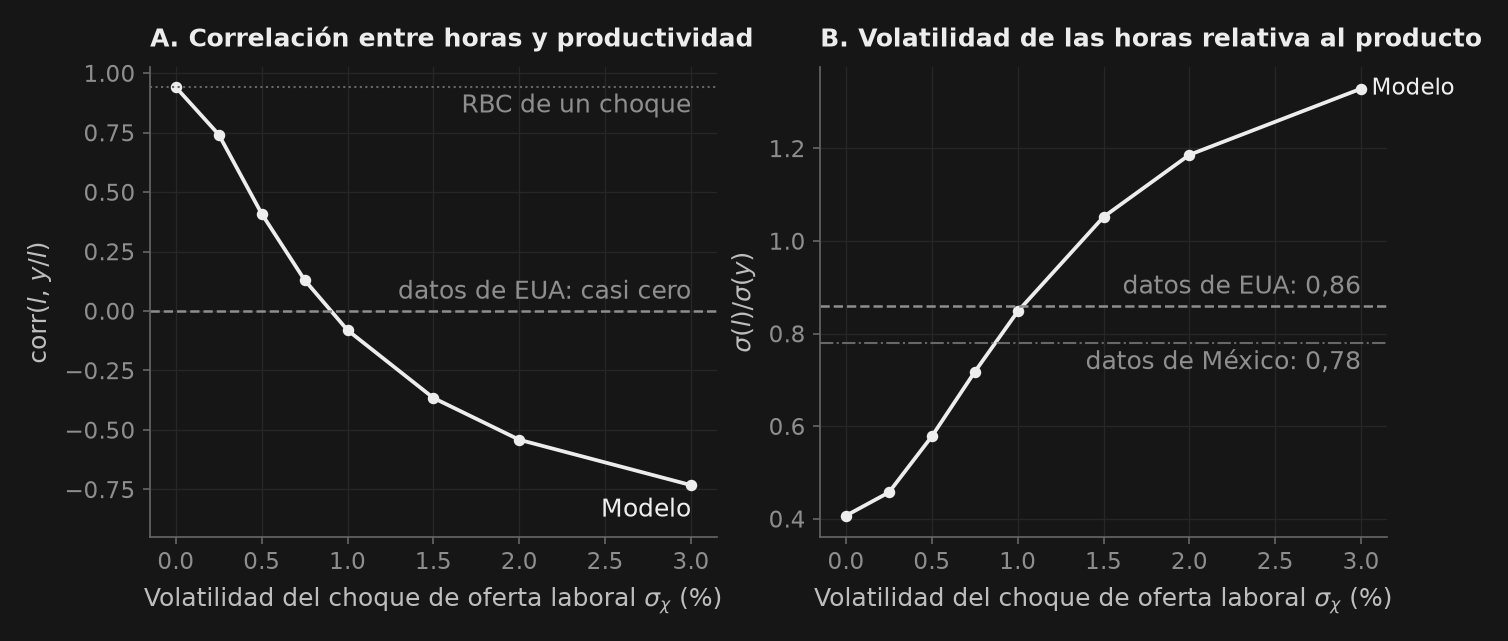

BARRIDO DEL CHOQUE DE OFERTA LABORAL (filtrado con HP, 2.000 trimestres por corrida):
 sigma_chi  sigma(y) %  sigma(l)/sigma(y)  sigma(c)/sigma(y)  corr(l, y/l)  corr(l, y)
     0.000       1.230              0.407              0.336         0.941       0.979
     0.002       1.238              0.457              0.334         0.742       0.912
     0.005       1.272              0.578              0.329         0.409       0.829
     0.008       1.332              0.717              0.322         0.130       0.797
     0.010       1.414              0.848              0.314        -0.081       0.799
     0.015       1.630              1.052              0.299        -0.365       0.838
     0.020       1.895              1.186              0.287        -0.541       0.877
     0.030       2.509              1.329              0.272        -0.732       0.928

corr(l, y/l) cruza cero en sigma_chi = 0.90%.
Con esa misma volatilidad el modelo entrega sigma(l)/sigma(y) = 0.80 frente al 0,86 

In [10]:
# ==============================================================================
# Añadir un Choque de Oferta Laboral (Preferencias): chi_t en la Condición Intratemporal
# ==============================================================================
labor_shock_mod = f"""
var y c k l i w r a chi;
varexo e_a e_chi;

parameters alpha beta delta mu nu rho_a rho_chi;
alpha   = 0.33;
beta    = 0.99;
delta   = 0.025;
mu      = {ss_rbc['mu']!r};
nu      = 1.5;
rho_a   = 0.95;
rho_chi = 0.90;

model;
mu * exp(chi) * (1 - l)^(-nu) * c = w;
c(+1)/(beta*c) = r(+1) + 1 - delta;
r = alpha * y / k(-1);
w = (1 - alpha) * y / l;
y = exp(a) * k(-1)^alpha * l^(1-alpha);
y = c + i;
k = (1 - delta)*k(-1) + i;
a = rho_a * a(-1) + e_a;
chi = rho_chi * chi(-1) + e_chi;
end;

initval;
y = {ss_rbc['y']!r};
c = {ss_rbc['c']!r};
i = {ss_rbc['i']!r};
k = {ss_rbc['k']!r};
l = {ss_rbc['l']!r};
w = {ss_rbc['w']!r};
r = {ss_rbc['r']!r};
a = 0.0;
chi = 0.0;
end;

shocks;
var e_a;   stderr 0.007;
var e_chi; stderr 0.010;
end;
"""

# Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo en l = 1, donde (1-l)^(-nu) = 0^(-nu); ese valor se descarta
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    m_chi = load_mod(labor_shock_mod)
assert m_chi.solution.eu == (1, 1), "El RBC de dos choques debe conservar un equilibrio estable único."

sigma_chi_grid = np.array([0.0, 0.0025, 0.005, 0.0075, 0.010, 0.015, 0.020, 0.030])
chi_rows = []
for sd_chi in sigma_chi_grid:
    cyc_chi = filtered_cycles(m_chi, periods=2000, seed=4242, sigma={"e_a": 0.007, "e_chi": float(sd_chi)})
    cyc_chi["prod"] = cyc_chi["y"] - cyc_chi["l"]
    s_chi = cyc_chi.std()
    chi_rows.append({
        "sigma_chi": sd_chi,
        "sigma(y) %": s_chi["y"],
        "sigma(l)/sigma(y)": s_chi["l"] / s_chi["y"],
        "sigma(c)/sigma(y)": s_chi["c"] / s_chi["y"],
        "corr(l, y/l)": cyc_chi["l"].corr(cyc_chi["prod"]),
        "corr(l, y)": cyc_chi["l"].corr(cyc_chi["y"]),
    })
chi_df = pd.DataFrame(chi_rows)

# Cuota de la varianza de las horas atribuible a la tecnología en el caso base sigma_chi = 0.01
fevd_chi = m_chi.fevd(horizons=(1, 4, 8, None), sigma={"e_a": 0.007, "e_chi": 0.010})
tech_share_l = float(fevd_chi.xs("l", level="Variable")["e_a"].iloc[-1])   # última fila = horizonte incondicional

fig, (ax_corr, ax_vol) = _nbstyle.figura(1, 2)
x_der = float(chi_df["sigma_chi"].max() * 100)   # borde derecho de los rótulos de referencia

# Panel A: la correlación entre horas y productividad
ax_corr.plot(chi_df["sigma_chi"] * 100, chi_df["corr(l, y/l)"], color=_nbstyle.UNIVERSAL_COLORS[0],
             lw=1.8, ls="-", marker="o", markersize=4.5)
ax_corr.axhline(0.0, color=_nbstyle.NOTA, ls="--", lw=1.2)
ax_corr.axhline(chi_df["corr(l, y/l)"].iloc[0], color=_nbstyle.SPINE, ls=":", lw=1.0)
ax_corr.annotate("Modelo", xy=(x_der, chi_df["corr(l, y/l)"].iloc[-1]), xytext=(0, -6), textcoords="offset points",
                 ha="right", va="top", color=_nbstyle.TINTA)
ax_corr.annotate("datos de EUA: casi cero", xy=(x_der, 0.0), xytext=(0, 3), textcoords="offset points",
                 ha="right", va="bottom", color=_nbstyle.NOTA)
ax_corr.annotate("RBC de un choque", xy=(x_der, chi_df["corr(l, y/l)"].iloc[0]), xytext=(0, -3), textcoords="offset points",
                 ha="right", va="top", color=_nbstyle.NOTA)
ax_corr.set_ylim(bottom=-0.95)
ax_corr.set_title("A. Correlación entre horas y productividad")
ax_corr.set_xlabel(r"Volatilidad del choque de oferta laboral $\sigma_\chi$ (%)")
ax_corr.set_ylabel(r"corr($l$, $y/l$)")

# Panel B: volatilidad relativa de las horas
ax_vol.plot(chi_df["sigma_chi"] * 100, chi_df["sigma(l)/sigma(y)"], color=_nbstyle.UNIVERSAL_COLORS[0],
            lw=1.8, ls="-", marker="o", markersize=4.5, label="Modelo")
ax_vol.axhline(0.86, color=_nbstyle.NOTA, ls="--", lw=1.2)
ax_vol.axhline(0.78, color=_nbstyle.SPINE, ls="-.", lw=1.0)
ax_vol.annotate("datos de EUA: 0,86", xy=(x_der, 0.86), xytext=(0, 3), textcoords="offset points",
                ha="right", va="bottom", color=_nbstyle.NOTA)
ax_vol.annotate("datos de México: 0,78", xy=(x_der, 0.78), xytext=(0, -3), textcoords="offset points",
                ha="right", va="top", color=_nbstyle.NOTA)
ax_vol.set_title("B. Volatilidad de las horas relativa al producto")
ax_vol.set_xlabel(r"Volatilidad del choque de oferta laboral $\sigma_\chi$ (%)")
ax_vol.set_ylabel(r"$\sigma(l)/\sigma(y)$")
_nbstyle.etiquetar(ax_vol)

plt.show()

print("BARRIDO DEL CHOQUE DE OFERTA LABORAL (filtrado con HP, 2.000 trimestres por corrida):")
print(chi_df.round(3).to_string(index=False))

# ¿Dónde cruza cero la correlación, y qué entrega el modelo ahí?
sigma_zero = float(np.interp(0.0, chi_df["corr(l, y/l)"].values[::-1], chi_df["sigma_chi"].values[::-1]))
l_ratio_at_zero = float(np.interp(sigma_zero, chi_df["sigma_chi"], chi_df["sigma(l)/sigma(y)"]))
print(f"\ncorr(l, y/l) cruza cero en sigma_chi = {sigma_zero*100:.2f}%.")
print(f"Con esa misma volatilidad el modelo entrega sigma(l)/sigma(y) = {l_ratio_at_zero:.2f} frente al 0,86 de EUA.")
print(f"La tecnología explica entonces solo el {tech_share_l:.1f}% de la varianza incondicional de las horas "
      "(100% en el modelo de un choque).")

assert chi_df["corr(l, y/l)"].iloc[0] > 0.8, "El referente de un choque debe mostrar una correlación casi perfecta."
assert chi_df["corr(l, y/l)"].iloc[-1] < 0.0, "Un choque de oferta laboral suficientemente grande debe volver negativa la correlación."
assert l_ratio_at_zero > 1.8 * chi_df["sigma(l)/sigma(y)"].iloc[0], (
    "Arreglar la correlación debe además duplicar aproximadamente la volatilidad relativa de las horas."
)
assert l_ratio_at_zero > 0.7, "El modelo corregido debe quedar cerca de la volatilidad relativa de las horas de EUA."
assert tech_share_l < 60.0, "La tecnología debe dejar de ser el impulsor dominante de las horas."
print("\nAserciones de oferta laboral superadas: un choque faltante repara dos «fracasos» a la vez.")

## Por Qué el Consumo Es Demasiado Suave: ¿Persistencia o Choques a la Tendencia?

El único fracaso que el choque de oferta laboral *no* repara es el suavizamiento del consumo: $\sigma_c/\sigma_y$ se queda entre $0{,}34$ y $0{,}27$ en todo el barrido anterior, y en datos mexicanos es $0{,}96$. La sección 3 nombró tres reparaciones candidatas. Dos de ellas pueden medirse dentro de este cuaderno.

**Candidata 1 — choques más persistentes.** La lógica del ingreso permanente dice que el hogar consume el valor de anualidad de un golpe de suerte. Cuanto más persistente el choque, mayor la porción del ingreso corriente que es permanente, y más debería moverse el consumo. Barrer $\rho_a$ de $0{,}5$ a $0{,}995$ mide hasta dónde puede llegar la persistencia por sí sola.

**Candidata 2 — choques a la tendencia misma (Aguiar y Gopinath 2007).** Su tesis sobre los mercados emergentes es que «el ciclo es la tendencia»: la perturbación dominante no es una desviación transitoria alrededor de una senda de crecimiento estable, sino un choque a la **tasa de crecimiento** de la productividad, $\Delta \log \Gamma_t = g_t$. Un choque de crecimiento eleva el ingreso permanente más que el corriente, de modo que el consumo puede subir más que el producto. Construimos ese modelo en forma destendencializada —cada variable escalada por $\Gamma_t$, de manera que $e^{g_t}$ aparece en la función de producción, en la ley de acumulación de capital, en la tasa de renta y en la ecuación de Euler— con crecimiento medio nulo para que el estado estacionario, y por tanto $\mu$, sea idéntico al del caso base. El producto observado se reconstruye después como $\log Y_t = \log \hat y_t + \sum_{s \le t} g_s$ antes de filtrar, exactamente como Aguiar y Gopinath tratan los datos.

Ambos experimentos mueven al modelo en la dirección correcta. Ninguno cierra la brecha — y vale la pena adelantar la razón: en una economía **cerrada** $c + i = y$ cada trimestre, así que un consumo muy volátil tiene que pagarse con una inversión mucho menos volátil o mucho menos procíclica que en los datos. Es precisamente por eso que la literatura de mercados emergentes se movió a economías pequeñas y abiertas con acceso a endeudamiento externo (Neumeyer y Perri 2005, García-Cicco, Pancrazi y Uribe 2010).

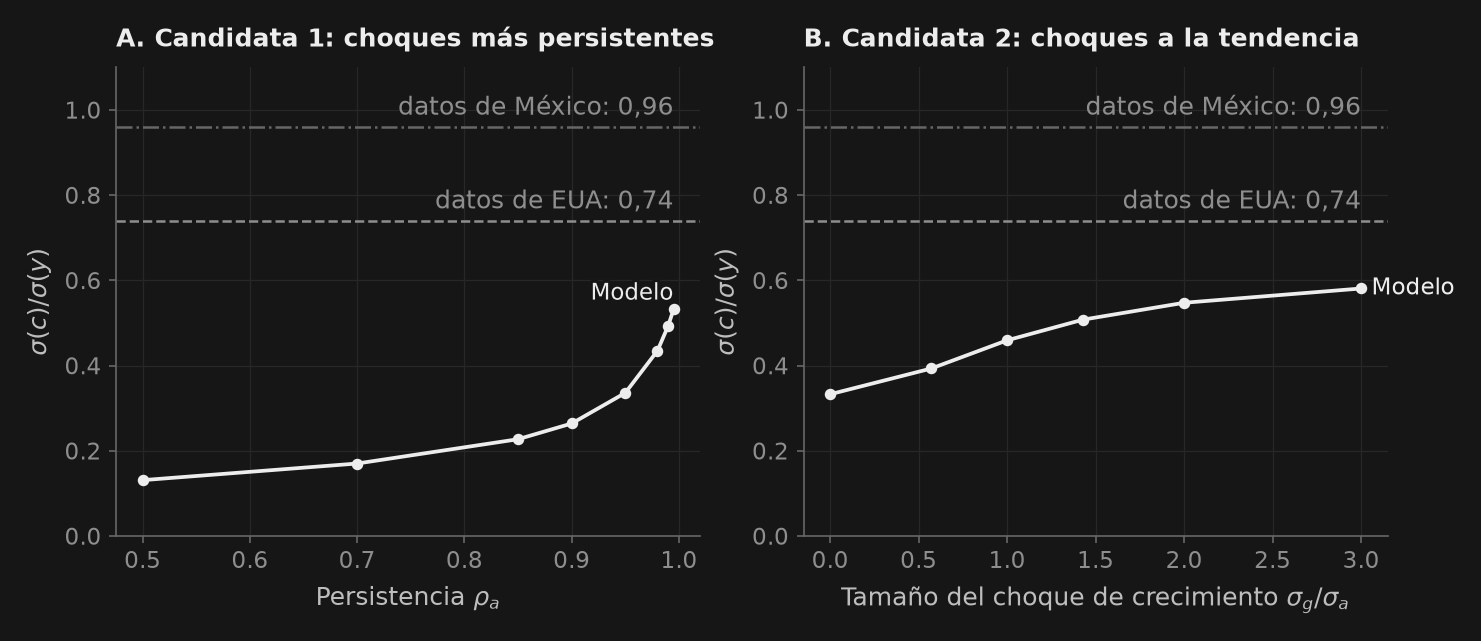

CANDIDATA 1 -- PERSISTENCIA DEL CHOQUE TRANSITORIO:
 rho_a  sigma(y) %  sigma(c)/sigma(y)  sigma(i)/sigma(y)  corr(c, y)
 0.500       1.110              0.131              4.059       0.521
 0.700       1.209              0.170              3.958       0.606
 0.850       1.300              0.227              3.762       0.739
 0.900       1.309              0.264              3.615       0.811
 0.950       1.273              0.336              3.324       0.902
 0.980       1.202              0.435              2.944       0.958
 0.990       1.171              0.494              2.728       0.973
 0.995       1.172              0.532              2.590       0.980

CANDIDATA 2 -- CHOQUES A LA TASA DE CRECIMIENTO (Aguiar-Gopinath):
 sigma_g / sigma_a  sigma(y) %  sigma(c)/sigma(y)  sigma(i)/sigma(y)  corr(c, y)
             0.000       1.253              0.333              3.325       0.906
             0.571       1.377              0.393              3.199       0.890
             1.0

In [11]:
# ==============================================================================
# Candidata 1: Persistencia del Choque -- Candidata 2: Choques a la Tasa de Crecimiento
# ==============================================================================
rho_grid = [0.50, 0.70, 0.85, 0.90, 0.95, 0.98, 0.99, 0.995]
rho_rows = []
for rho_v in rho_grid:
    # Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo en l = 1, donde (1-l)^(-nu) = 0^(-nu); ese valor se descarta
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
        m_rho = load_mod(rbc_mod_path, params={"mu": ss_rbc["mu"], "rho_a": rho_v})
    cyc_rho = filtered_cycles(m_rho, periods=2000, seed=515)
    s_rho = cyc_rho.std()
    rho_rows.append({"rho_a": rho_v, "sigma(y) %": s_rho["y"],
                     "sigma(c)/sigma(y)": s_rho["c"] / s_rho["y"],
                     "sigma(i)/sigma(y)": s_rho["i"] / s_rho["y"],
                     "corr(c, y)": cyc_rho["c"].corr(cyc_rho["y"])})
rho_df = pd.DataFrame(rho_rows)

# Aguiar-Gopinath: modelo estacionario en unidades de la tendencia estocástica Gamma_t
trend_shock_mod = f"""
var y c k l i w r a g;
varexo e_a e_g;

parameters alpha beta delta mu nu rho_a rho_g;
alpha   = 0.33;
beta    = 0.99;
delta   = 0.025;
mu      = {ss_rbc['mu']!r};
nu      = 1.5;
rho_a   = 0.95;
rho_g   = 0.30;

model;
mu * (1 - l)^(-nu) * c = w;
c(+1)*exp(g(+1))/(beta*c) = r(+1) + 1 - delta;
r = alpha * y * exp(g) / k(-1);
w = (1 - alpha) * y / l;
y = exp(a) * (k(-1)*exp(-g))^alpha * l^(1-alpha);
y = c + i;
k = (1 - delta)*k(-1)*exp(-g) + i;
a = rho_a * a(-1) + e_a;
g = rho_g * g(-1) + e_g;
end;

initval;
y = {ss_rbc['y']!r};
c = {ss_rbc['c']!r};
i = {ss_rbc['i']!r};
k = {ss_rbc['k']!r};
l = {ss_rbc['l']!r};
w = {ss_rbc['w']!r};
r = {ss_rbc['r']!r};
a = 0.0;
g = 0.0;
end;

shocks;
var e_a; stderr 0.007;
var e_g; stderr 0.007;
end;
"""

# Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo en l = 1, donde (1-l)^(-nu) = 0^(-nu); ese valor se descarta
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    m_trend = load_mod(trend_shock_mod)
assert m_trend.solution.eu == (1, 1), "El modelo con choques a la tendencia debe tener un equilibrio estable único."


def trend_cycles(sd_g, periods=2000, seed=808):
    """Reconstruye las series logarítmicas observadas (sin destendencializar) sumando la tendencia estocástica."""
    raw = m_trend.simulate(periods=periods, seed=seed, burn=300, sigma={"e_a": 0.007, "e_g": float(sd_g)})
    log_gamma = np.cumsum(raw["g"].values) * 100.0
    logs = {v: 100.0 * np.log((SS_LEVELS[v] + raw[v].values) / SS_LEVELS[v]) + log_gamma for v in ("y", "c", "i")}
    logs["l"] = 100.0 * np.log((SS_LEVELS["l"] + raw["l"].values) / SS_LEVELS["l"])
    return pd.DataFrame({v: hp_filter(pd.Series(s), lamb=1600.0)[0].values for v, s in logs.items()})


sigma_g_grid = [0.0, 0.004, 0.007, 0.010, 0.014, 0.021]
trend_rows = []
for sd_g in sigma_g_grid:
    cyc_g = trend_cycles(sd_g)
    s_g = cyc_g.std()
    trend_rows.append({"sigma_g / sigma_a": sd_g / 0.007, "sigma(y) %": s_g["y"],
                       "sigma(c)/sigma(y)": s_g["c"] / s_g["y"],
                       "sigma(i)/sigma(y)": s_g["i"] / s_g["y"],
                       "corr(c, y)": cyc_g["c"].corr(cyc_g["y"])})
trend_df = pd.DataFrame(trend_rows)

fig, (ax_rho, ax_trend) = _nbstyle.figura(1, 2)

for ax, xdata, ydata, xlabel, title in (
    (ax_rho, rho_df["rho_a"], rho_df["sigma(c)/sigma(y)"], r"Persistencia $\rho_a$",
     "A. Candidata 1: choques más persistentes"),
    (ax_trend, trend_df["sigma_g / sigma_a"], trend_df["sigma(c)/sigma(y)"],
     r"Tamaño del choque de crecimiento $\sigma_g / \sigma_a$", "B. Candidata 2: choques a la tendencia"),
):
    ax.plot(xdata, ydata, color=_nbstyle.UNIVERSAL_COLORS[0], lw=1.8, ls="-", marker="o", markersize=4.5, label="Modelo")
    ax.axhline(0.74, color=_nbstyle.NOTA, ls="--", lw=1.2)
    ax.axhline(0.96, color=_nbstyle.SPINE, ls="-.", lw=1.2)
    for nivel, texto in ((0.74, "datos de EUA: 0,74"), (0.96, "datos de México: 0,96")):
        ax.annotate(texto, xy=(float(xdata.max()), nivel), xytext=(0, 3), textcoords="offset points",
                    ha="right", va="bottom", color=_nbstyle.NOTA)
    ax.set_ylim(0.0, 1.1)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$\sigma(c)/\sigma(y)$")
    _nbstyle.etiquetar(ax)

plt.show()

print("CANDIDATA 1 -- PERSISTENCIA DEL CHOQUE TRANSITORIO:")
print(rho_df.round(3).to_string(index=False))
print("\nCANDIDATA 2 -- CHOQUES A LA TASA DE CRECIMIENTO (Aguiar-Gopinath):")
print(trend_df.round(3).to_string(index=False))

best_rho = float(rho_df["sigma(c)/sigma(y)"].max())
best_trend = float(trend_df["sigma(c)/sigma(y)"].max())
print(f"\nCaso base (rho_a = 0,95, sin choque a la tendencia): sigma(c)/sigma(y) = {rho_df.loc[4, 'sigma(c)/sigma(y)']:.2f}")
print(f"Mejor alcanzable solo con persistencia             : {best_rho:.2f} (con rho_a = 0,995, casi un paseo aleatorio)")
print(f"Mejor alcanzable con choques a la tendencia        : {best_trend:.2f} (con sigma_g = 3 veces sigma_a)")
print("Ninguno llega al 0,74 de EUA, mucho menos al 0,96 de México: en economía cerrada c + i = y ata cada trimestre.")

assert best_rho > 1.4 * rho_df.loc[4, "sigma(c)/sigma(y)"], "La persistencia debe elevar sustancialmente la volatilidad del consumo."
assert best_trend > best_rho, "Los choques a la tendencia deben superar a la persistencia dentro de la familia estacionaria."
assert best_trend < 0.74, "Una economía cerrada debe seguir quedándose corta frente a la razón de EUA."
print("\nAserciones de suavizamiento del consumo superadas: la brecha restante es una cuestión de economía abierta, no de calibración.")

## Recuperación Empírica en Espacio de Estados: Suavizamiento de Kalman y Descomposición de Choques en Crisis

La calibración y la simulación estocástica evalúan si una economía RBC *puede* replicar momentos incondicionales bajo distribuciones teóricas de perturbaciones. Una pregunta empírica distinta es: **¿qué trayectoria estructural no observada atravesó realmente la economía durante episodios históricos de crisis?**

Dado que el acervo de capital $k_t$ y las innovaciones de Solow $e_{a,t}$ no se observan directamente en las cuentas nacionales con frecuencia trimestral, su extracción exige invertir la representación de espacio de estados del modelo mediante el suavizador de Kalman (Hamilton 1994, Durbin & Koopman 2012). Para un DSGE lineal resuelto:
$$x_t = A x_{t-1} + B \varepsilon_t$$
$$y_t = d + Z x_t + \eta_t$$

`puremacro.dsge.LinearModel.smoother(data, varobs=...)` calcula las esperanzas condicionales bilaterales $\mathbb{E}[x_t \mid \mathcal{Y}_T]$ y los choques estructurales $\mathbb{E}[\varepsilon_t \mid \mathcal{Y}_T]$ sobre la muestra histórica completa $\mathcal{Y}_T = \{y_1, \dots, y_T\}$. Asimismo, `sm.shock_decomposition()` descompone la senda histórica de cada variable observable en:
$$y_t = y_{ss} + \text{Condición Inicial}_t + \sum_{s \le t} \mathcal{H}_{t-s} \varepsilon_s + \text{residual}_t$$

A continuación, alimentamos el PIB real observado de EUA en el modelo RBC canónico sobre la ventana 2005Q1–2024Q4, aislando los residuos de Solow estructurales durante dos crisis macroeconómicas determinantes: la **Gran Crisis Financiera (GFC) de 2008** y el **colapso por COVID-19 de 2020**. A partir del estado filtrado terminal $(\hat{x}_T, P_T)$, `LinearModel.forecast(horizon=12)` proyecta abanicos dinámicos consistentes con el modelo e intervalos de confianza al 90% determinados por la incertidumbre de choques estructurales.

SUAVIZAMIENTO DE KALMAN: EXTRACCIÓN DE CHOQUES EN EPISODIOS DE CRISIS
Choque de PTF en Gran Crisis Financiera 2008Q4 e_a :  -1.69%
Choque de PTF en Confinamiento COVID-19 2020Q2 e_a   :  -6.37%
Acervo de Capital Filtrado Terminal (desv. k_T)      : +0.0033


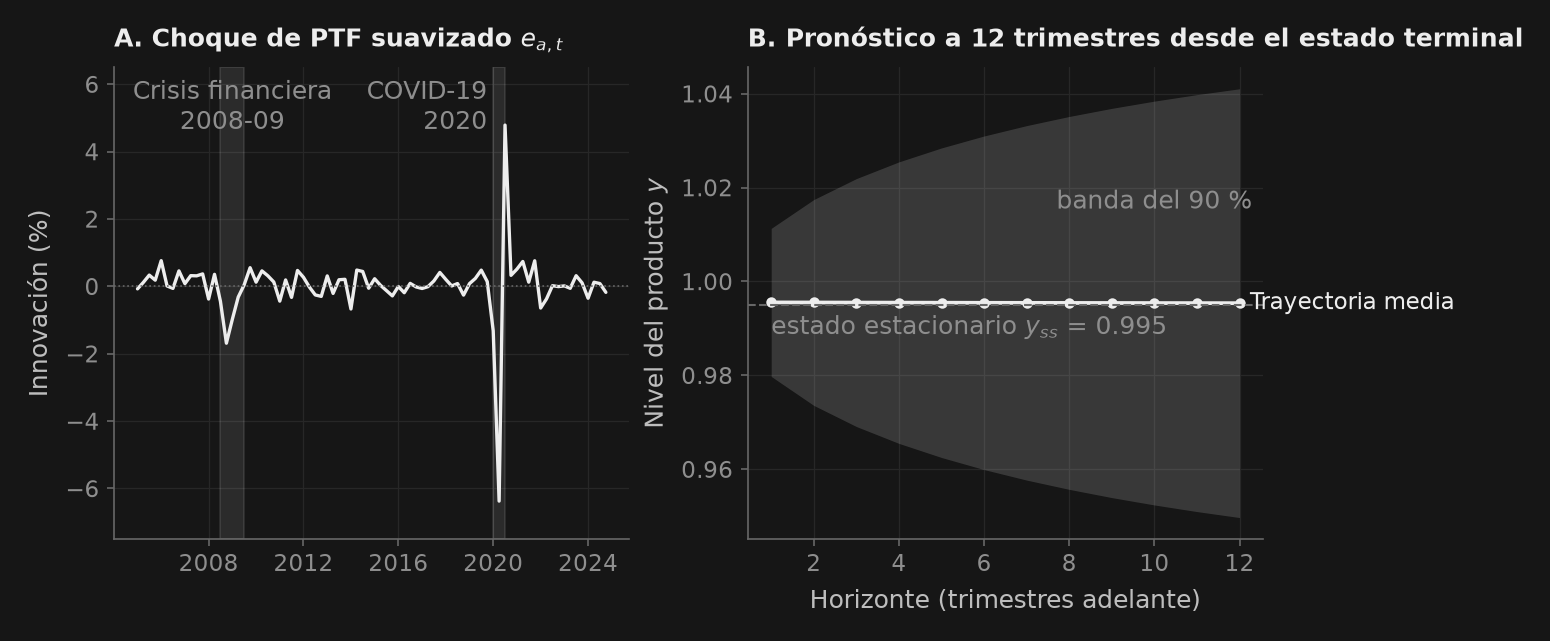


¡Aserciones del suavizador de Kalman y pronóstico dinámico superadas exitosamente!


In [12]:
# ==============================================================================
# Recuperación en Espacio de Estados: Suavizamiento de Kalman y Pronóstico Dinámico
# ==============================================================================
# 1. Cargar PIB real trimestral observado de EUA
gdp_data_path = ruta_dato("GDPC1.csv")

gdp_df = pd.read_csv(gdp_data_path)
gdp_df["date"] = pd.to_datetime(gdp_df["observation_date"])
gdp_df = gdp_df.set_index("date").sort_index()

# Extraer ventana de crisis 2005Q1 a 2024Q4 (abarcando GFC 2008 y COVID-19 2020)
hist_sample = gdp_df.loc["2005-01-01":"2024-10-01"].copy()
cycle_gdp, _ = hp_filter(np.log(hist_sample["GDPC1"]), lamb=1600.0)
hist_sample["cycle"] = cycle_gdp

# Centrar la serie observable en el nivel de estado estacionario del modelo
y_ss = float(m_rbc.steady_state["y"])
hist_sample["y"] = y_ss * (1.0 + hist_sample["cycle"])
data_rbc = hist_sample[["y"]]

# 2. Suavizamiento de Kalman
sm_rbc = m_rbc.smoother(data_rbc, varobs=["y"])

# 3. Pronóstico dinámico DSGE a H=12 trimestres desde el estado filtrado terminal
fc_rbc = m_rbc.forecast(horizon=12, data=data_rbc, varobs=["y"], ci=0.90)

# 4. Diagnóstico de episodios de crisis
gfc_shock = float(sm_rbc.shocks.loc["2008-10-01", "e_a"])
covid_shock = float(sm_rbc.shocks.loc["2020-04-01", "e_a"])

print("=" * 76)
print("SUAVIZAMIENTO DE KALMAN: EXTRACCIÓN DE CHOQUES EN EPISODIOS DE CRISIS")
print("=" * 76)
print(f"Choque de PTF en Gran Crisis Financiera 2008Q4 e_a : {gfc_shock * 100:+6.2f}%")
print(f"Choque de PTF en Confinamiento COVID-19 2020Q2 e_a   : {covid_shock * 100:+6.2f}%")
print(f"Acervo de Capital Filtrado Terminal (desv. k_T)      : {sm_rbc.states['k'].iloc[-1]:+6.4f}")
print("=" * 76)

# 5. Visualización de perturbaciones históricas suavizadas y abanico de pronóstico
fig, (ax_shk, ax_fc) = _nbstyle.figura(1, 2)

# Panel A: Choques de PTF históricos suavizados
ax_shk.plot(sm_rbc.shocks.index, sm_rbc.shocks["e_a"] * 100.0, color=_nbstyle.UNIVERSAL_COLORS[0], lw=1.6, ls="-")
ax_shk.axhline(0, color=_nbstyle.SPINE, ls=":", lw=0.8)
ax_shk.axvspan(pd.Timestamp("2008-07-01"), pd.Timestamp("2009-06-30"), color=_nbstyle.RECESION)
ax_shk.axvspan(pd.Timestamp("2020-01-01"), pd.Timestamp("2020-07-01"), color=_nbstyle.RECESION)
ax_shk.set_ylim(-7.5, 6.5)
ax_shk.text(pd.Timestamp("2009-01-01"), 6.2, "Crisis financiera\n2008-09", ha="center", va="top", color=_nbstyle.NOTA)
ax_shk.text(pd.Timestamp("2019-10-01"), 6.2, "COVID-19\n2020", ha="right", va="top", color=_nbstyle.NOTA)
ax_shk.set_title("A. Choque de PTF suavizado $e_{a,t}$")
ax_shk.set_ylabel("Innovación (%)")

# Panel B: Abanico de pronóstico DSGE
h_axis = np.arange(1, 13)
y_mean = fc_rbc.mean["y"].values
y_low = fc_rbc.lower["y"].values
y_upp = fc_rbc.upper["y"].values

ax_fc.plot(h_axis, y_mean, color=_nbstyle.UNIVERSAL_COLORS[0], lw=1.8, ls="-", marker="o", markersize=4, label="Trayectoria media")
ax_fc.fill_between(h_axis, y_low, y_upp, color=_nbstyle.BANDA, lw=0)
ax_fc.axhline(y_ss, color=_nbstyle.SPINE, ls="--", lw=1.0)
ax_fc.annotate(f"estado estacionario $y_{{ss}}$ = {y_ss:.3f}", xy=(h_axis[0], y_ss), xytext=(0, -5), textcoords="offset points",
               ha="left", va="top", color=_nbstyle.NOTA)
ax_fc.text(h_axis[-3], (y_mean[-3] + y_upp[-3]) / 2, "banda del 90 %", ha="center", va="center", color=_nbstyle.NOTA)
ax_fc.set_title("B. Pronóstico a 12 trimestres desde el estado terminal")
ax_fc.set_xlabel("Horizonte (trimestres adelante)")
ax_fc.set_ylabel("Nivel del producto $y$")
_nbstyle.etiquetar(ax_fc)

plt.show()

# Aserciones de verificación
assert gfc_shock < -0.015, f"El choque GFC debe ser contractivo: {gfc_shock}"
assert covid_shock < -0.05, f"El choque COVID debe ser fuertemente contractivo: {covid_shock}"
assert (fc_rbc.lower["y"] < fc_rbc.mean["y"]).all(), "La banda inferior debe situarse por debajo de la media."
assert (fc_rbc.upper["y"] > fc_rbc.mean["y"]).all(), "La banda superior debe situarse por encima de la media."
print("\n¡Aserciones del suavizador de Kalman y pronóstico dinámico superadas exitosamente!")

## Estimación Bayesiana y Moda Posterior: Confrontación de la Calibración Declarativa

La práctica macroeconómica rara vez descansa de manera exclusiva en parámetros calibrados; la macroeconometría moderna disciplina las elasticidades estructurales profundas mediante estimación basada en verosimilitud (An & Schorfheide 2007, Fernández-Villaverde 2010, Herbst & Schorfheide 2015).

`puremacro.dsge.LinearModel.estimate` vincula archivos declarativos `.mod` de Dynare directamente con la búsqueda numérica de la moda y el muestreo posterior MCMC vía Metropolis-Hastings de paseo aleatorio (RWMH):
1. **Priors Declarativos**: En el archivo `.mod`, la instrucción `varobs` declara las series observables, mientras que `estimated_params; ... end;` define las distribuciones a priori (e.g., Beta para la persistencia $\rho_a \in (0, 1)$, Inversa-Gamma para las desviaciones estándar $\sigma_a > 0$).
2. **Verosimilitud Automática en Espacio de Estados**: El resolvedor construye las matrices de observación que mapean estados latentes a observables, evaluando la log-verosimilitud gaussiana exacta mediante el filtro de Kalman.
3. **Diagnósticos Posteriores y Comparación de Modelos**: El resultado posterior (`DSGEPosteriorResult`) reporta la moda posterior, las extracciones MCMC, los cuantiles de los parámetros y la **densidad marginal de los datos de Laplace** $\log p(\mathcal{Y})$, habilitando la comparación bayesiana de modelos y razones de probabilidades posteriores.

A continuación, estimamos la persistencia de la PTF $\rho_a$ y la volatilidad de la innovación $\sigma_a$ sobre la serie empírica del PIB real de EUA, confrontando la calibración de libro de texto de Kydland-Prescott ($\rho_a = 0.95, \sigma_a = 0.007$) con los datos observados.

In [13]:
# ==============================================================================
# Estimación Bayesiana y de Moda vía Bloques Declarativos .mod
# ==============================================================================
# Construir especificación declarativa con bloques varobs y estimated_params
rbc_estim_mod_text = Path(rbc_mod_path).read_text() + """
varobs y;
estimated_params;
  rho_a, beta_pdf, 0.90, 0.05;
  stderr e_a, inv_gamma_pdf, 0.01, 2;
end;
"""

# Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo en l = 1, donde (1-l)^(-nu) = 0^(-nu); ese valor se descarta
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    m_rbc_est = load_mod(rbc_estim_mod_text)

# Ejecutar estimación bayesiana MCMC (RWMH con propuesta de Laplace basada en la moda)
print("Estimando parámetros estructurales del modelo RBC vía MCMC de puremacro...")
# Inofensivo: el solver de estado estacionario de puremacro prueba la firma del modelo en l = 1, donde (1-l)^(-nu) = 0^(-nu); ese valor se descarta
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", message="divide by zero encountered in scalar power", category=RuntimeWarning)
    res_rbc_est = m_rbc_est.estimate(data_rbc, n_draws=600, n_chains=2, burn_in=150, seed=42)

print("\n" + "=" * 76)
print("INFORME DE ESTIMACIÓN BAYESIANA DEL DSGE")
print("=" * 76)
print("Moda Posterior:")
for p_name, p_val in res_rbc_est.mode.items():
    print(f"  {p_name:<16}: {p_val:.6f}")

print("\nMomentos Posteriores e Intervalos de Credibilidad:")
summary_table = res_rbc_est.summary()
print(summary_table.round(5))

log_mdd_laplace = res_rbc_est.log_mdd("laplace")
print(f"\nDensidad Marginal de los Datos (Laplace) log p(Y) : {log_mdd_laplace:.4f}")
print("=" * 76)

# Aserciones de verificación
assert 0.50 < res_rbc_est.mode["rho_a"] < 1.0, f"Moda estimada de rho_a fuera de rango: {res_rbc_est.mode['rho_a']}"
assert 0.003 < res_rbc_est.mode["SE_e_a"] < 0.025, f"Moda estimada de SE_e_a fuera de rango: {res_rbc_est.mode['SE_e_a']}"
assert np.isfinite(log_mdd_laplace), "La densidad marginal logarítmica de Laplace debe ser finita."
print("\n¡Aserciones de estimación bayesiana superadas exitosamente!")

Estimando parámetros estructurales del modelo RBC vía MCMC de puremacro...

INFORME DE ESTIMACIÓN BAYESIANA DEL DSGE
Moda Posterior:
  rho_a           : 0.994140
  SE_e_a          : 0.008908

Momentos Posteriores e Intervalos de Credibilidad:
           mean      std       q5      q50      q95     mode
rho_a   0.99203  0.00345  0.98520  0.99250  0.99665  0.99414
SE_e_a  0.00912  0.00067  0.00801  0.00909  0.01021  0.00891

Densidad Marginal de los Datos (Laplace) log p(Y) : 215.4795

¡Aserciones de estimación bayesiana superadas exitosamente!
